Nora Payne (paynenor@gmail.com)

In [1]:
library(ggplot2)
library(tidyverse)
library(stringr)
library(MASS)

── Attaching packages ─────────────────────────────────────────────────────────────────────────── tidyverse 1.3.1 ──

✔ tibble  3.1.3     ✔ dplyr   1.0.7
✔ tidyr   1.1.3     ✔ stringr 1.4.0
✔ readr   2.0.1     ✔ forcats 0.5.1
✔ purrr   0.3.4     

── Conflicts ────────────────────────────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()


Attaching package: ‘MASS’


The following object is masked from ‘package:dplyr’:

    select




# Data checks

In [2]:
# CHECK:
# --- All files have same no. of rows?
filenames = list.files("train/", pattern="*.csv") %>% paste0("train/", .)

In [3]:
dims = sapply(filenames, function(fpath) {
    x = read.csv(fpath)
    return(dim(x))
})

In [4]:
dims %>% t

train/bottom.csv,1025,179
train/top.csv,1025,196
train/unlabeled_00.csv,1025,147
train/unlabeled_10.csv,1025,202
train/unlabeled_15.csv,1025,202
train/unlabeled_22.csv,1025,158
train/unlabeled_23.csv,1025,140
train/unlabeled_25.csv,1025,179
train/unlabeled_26.csv,1025,147
train/unlabeled_27.csv,1025,150
train/unlabeled_31.csv,1025,180


In [5]:
# --- All files have same colnames?
colnames = sapply(filenames, function(fpath) {
    x = read.csv(fpath)
    return(colnames(x))
})

In [6]:
all.equal(colnames[[1]], colnames[[2]])

[1] "Lengths (179, 196) differ (string compare on first 179)"

In [7]:
all.equal(colnames[[1]], colnames[[3]])

[1] "Lengths (179, 147) differ (string compare on first 147)"

In [8]:
# --- All files have same rownames?
rownames = sapply(filenames, function(fpath) {
    x = read.csv(fpath)
    return(x$frequency)
})

In [9]:
apply(rownames, 1, function(x) length(unique(x))) %>% table(useNA='always')

.
   1 <NA> 
1025    0 

Instances:
- Sampled at the same time points, but differ in length
- Same 1025 frequencies represented in every instance

# Labeled examples

In [10]:
top = read.csv("train/top.csv")
bottom = read.csv("train/bottom.csv")

print(dim(top))
print(dim(bottom))

[1] 1025  196
[1] 1025  179


In [11]:
head(top, 3)

,frequency,X0.0,X23.219954648526077,X46.439909297052154,X69.65986394557822,X92.87981859410431,X116.09977324263039,X139.31972789115645,X162.53968253968253,X185.75963718820861,⋯,X4295.691609977324,X4318.91156462585,X4342.131519274377,X4365.351473922902,X4388.571428571428,X4411.791383219955,X4435.011337868481,X4458.231292517006,X4481.4512471655335,X4504.671201814059
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,0.0000,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
2,10.7666,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
3,21.5332,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0


In [12]:
ifelse(top[,-1]==0, 0, 1) %>% colSums() %>% table

.
 0  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 19 20 25 50 70 
 5  1  3  5 14 14 25 25 20 13 18  8 12  8  6 10  2  2  1  1  1  1 

In [13]:
ifelse(top[,-1]==0, 0, 1) %>% rowSums() %>% table

.
  0   1   2   3   4   5   6   7   8  10  12  14  16  18  19  20  21  22  23  24 
857  68  18   8   5   5   2   2   4   4   2   4   3   2   1   3   1   3   4   3 
 26  27  29  30  31  32  33  36  37  38  41  42  44  46  51  52  54  60  61  63 
  1   1   1   2   1   1   1   2   1   2   1   1   1   1   1   1   2   1   1   1 
 74  89 
  1   1 

In [14]:
ifelse(top[,-1]==0, 0, 1) %>% colSums() %>% head

X0.0 X23.219954648526077 X46.439909297052154  X69.65986394557822 
                  0                   0                   0                   0 
 X92.87981859410431 X116.09977324263039 
                  0                  25

In [15]:
ifelse(bottom[,-1]==0, 0, 1) %>% colSums() %>% head

X0.0 X23.219954648526077 X46.439909297052154  X69.65986394557822 
                  0                   0                   0                   0 
 X92.87981859410431 X116.09977324263039 
                  0                  19

In [16]:
top_long = top %>% 
    pivot_longer(!frequency, names_to = "time", values_to = "magnitude") %>% 
    mutate(time = as.numeric(substring(time, 2)))

head(top_long, 3)

frequency,time,magnitude
<dbl>,<dbl>,<dbl>
0,0.00000,0
0,23.21995,0
0,46.43991,0


In [17]:
bottom_long = bottom %>% 
    pivot_longer(!frequency, names_to = "time", values_to = "magnitude") %>% 
    mutate(time = as.numeric(substring(time, 2)) )

head(bottom_long, 3)

frequency,time,magnitude
<dbl>,<dbl>,<dbl>
0,0.00000,0
0,23.21995,0
0,46.43991,0


[1] 1065.894


Warning message:
“Removed 22 rows containing missing values (geom_point).”
Warning message:
“Removed 22 row(s) containing missing values (geom_path).”
Warning message:
“Removed 5 rows containing missing values (geom_point).”
Warning message:
“Removed 5 row(s) containing missing values (geom_path).”


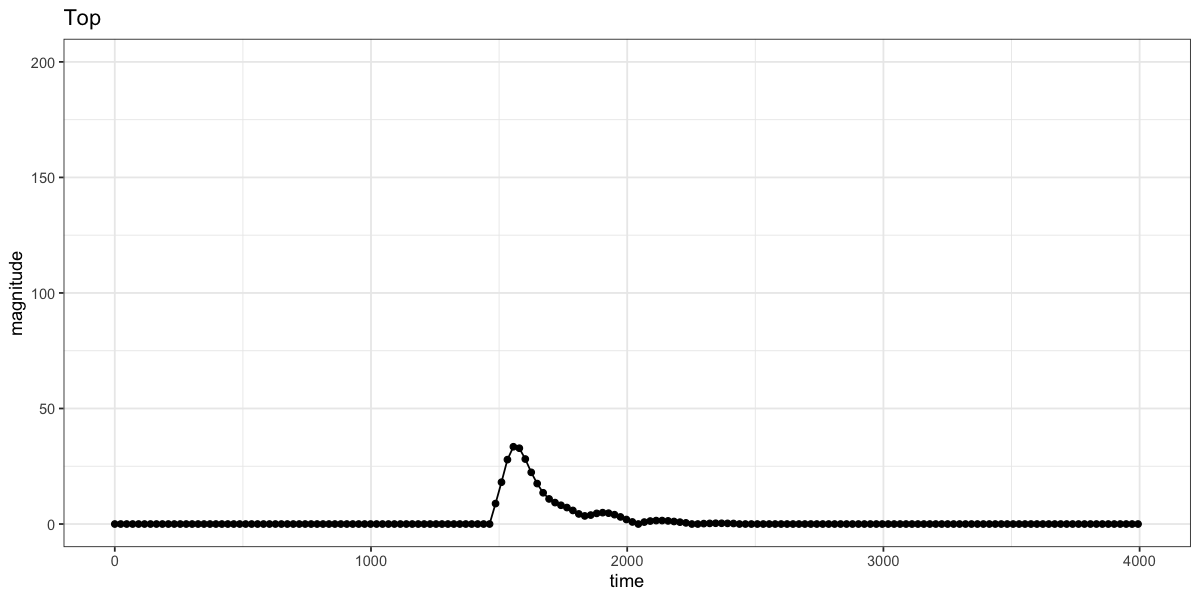

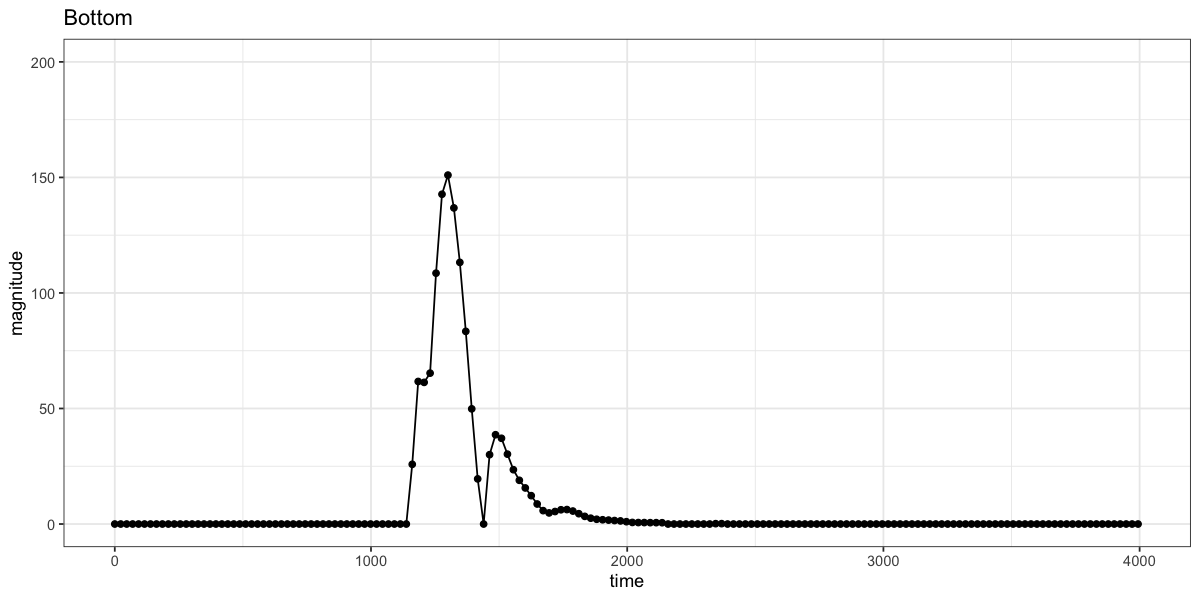

In [18]:
options(repr.plot.width = 10, repr.plot.height = 5)
f0 = top$frequency[100]
print(f0)

top_long %>% 
    filter(frequency == f0) %>%
    ggplot(aes(x = time, y = magnitude)) +
    geom_point() +
    geom_line() +
    theme_bw() +
    xlim(0, 4000) +
    ylim(0, 200) +
    ggtitle("Top")

bottom_long %>% 
    filter(frequency == f0) %>%
    ggplot(aes(x = time, y = magnitude)) +
    geom_point() +
    geom_line() +
    theme_bw() +
    xlim(0, 4000) +
    ylim(0, 200) +
    ggtitle("Bottom")

In [19]:
range(top_long$magnitude)

[1]  0.00000 78.79987

In [20]:
filter(top_long, magnitude > 70)

frequency,time,magnitude
<dbl>,<dbl>,<dbl>
2971.582,1509.297,74.49649
2971.582,1532.517,75.21198
3036.182,1486.077,74.97609
3036.182,1509.297,78.79987


# Normalization

In [21]:
range(top_long$time) %>% print
range(bottom_long$time) %>% print

[1]    0.000 4504.671
[1]    0.000 4109.932


In [22]:
range(top_long$magnitude)
range(bottom_long$magnitude)

[1]  0.00000 78.79987

[1]   0.0000 151.0067

In [23]:
x = bottom_long %>%
    filter(time<4000) %>%
    group_by(frequency) %>%
    summarise(total = sum(magnitude)) %>%
    mutate(norm_total = total/sum(total),
           norm_total_peak = total/max(total))

y = top_long %>%
    filter(time<4000) %>%
    group_by(frequency) %>%
    summarise(total = sum(magnitude)) %>%
    mutate(norm_total = total/sum(total),
           norm_total_peak = total/max(total))

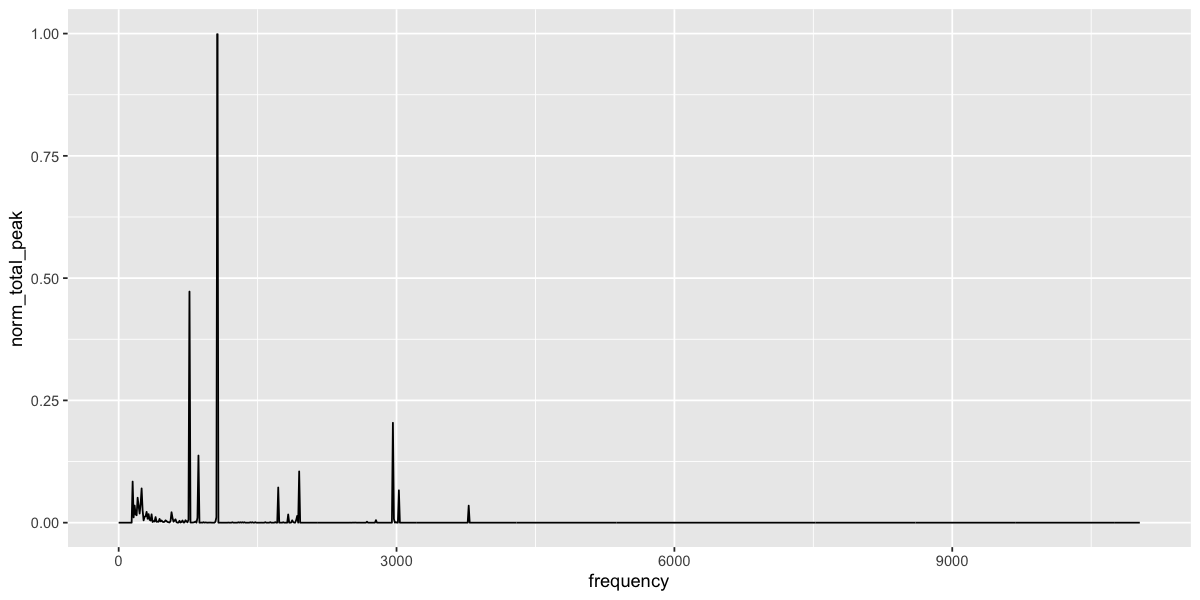

In [24]:
ggplot(x, aes(x = frequency, y = norm_total_peak)) + geom_line()

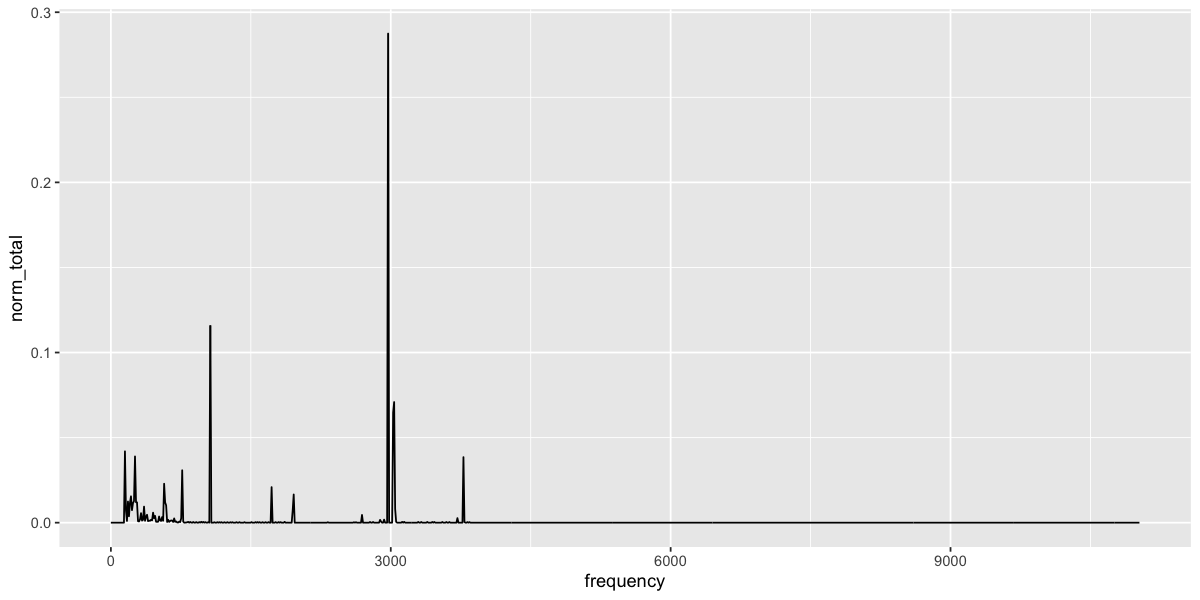

In [25]:
ggplot(y, aes(x = frequency, y = norm_total)) + geom_line()

In [26]:
range(bottom[,-1])

[1]   0.0000 151.0067

In [27]:
range(top[,-1])

[1]  0.00000 78.79987

In [28]:
mat_to_long = function(fpath) {
    data_matrix = read.csv(fpath)
    data_long = data_matrix %>% 
        pivot_longer(!frequency, names_to = "time", values_to = "magnitude") %>% 
        mutate(time = as.numeric(substring(time, 2)))
    return(data_long)
}

compute_pct = function(fpath) {
    data_long = mat_to_long(fpath)
    data_long = data_long %>%
        # filter(time<3000) %>%
        group_by(frequency) %>%
        summarise(total = sum(magnitude)) %>%
        mutate(norm_total = total/sum(total), norm_total_peak = total/max(total))
    return(data_long)
}

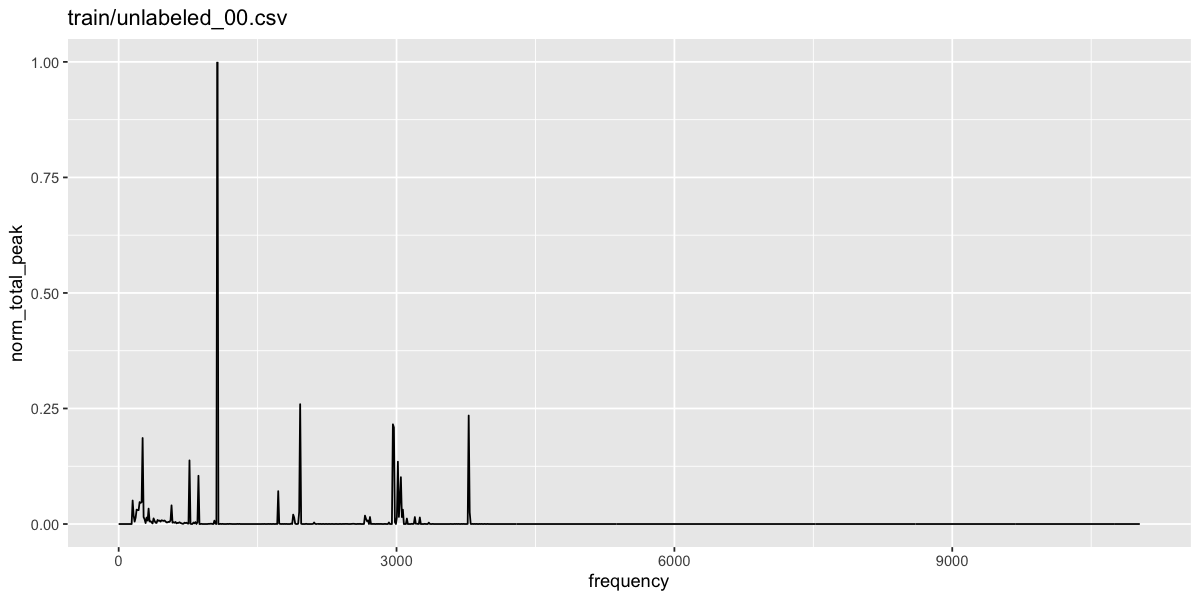

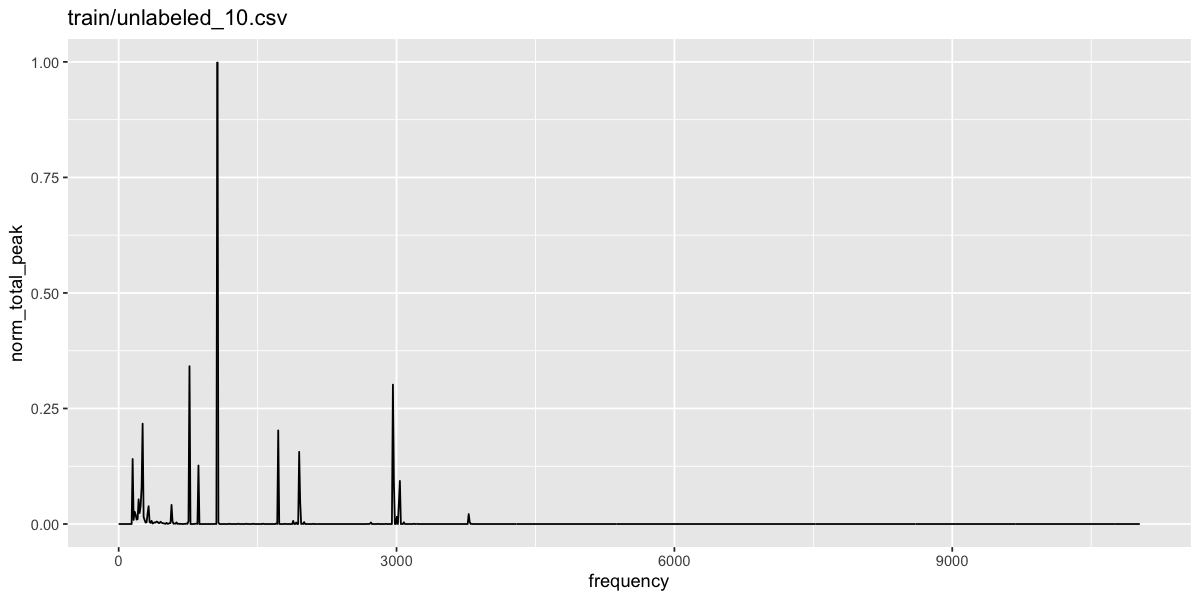

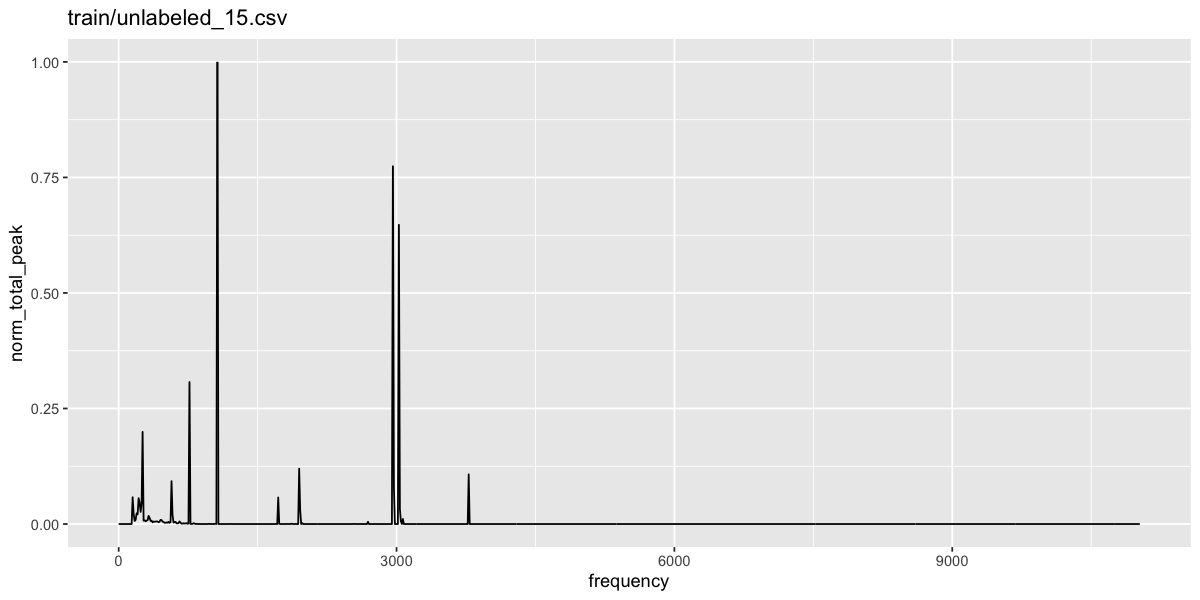

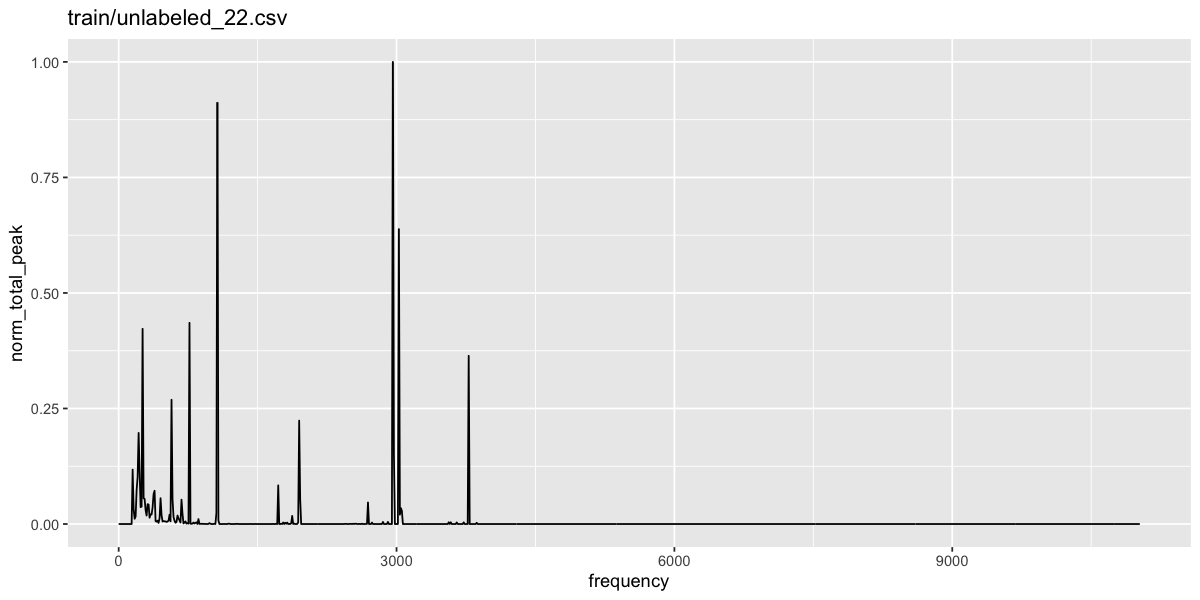

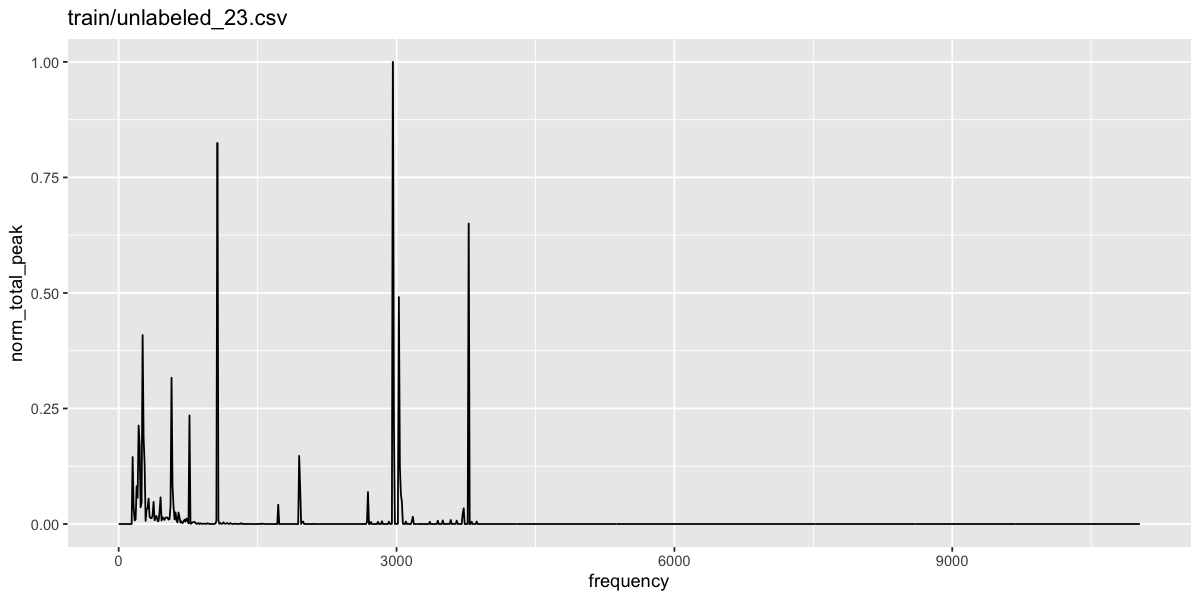

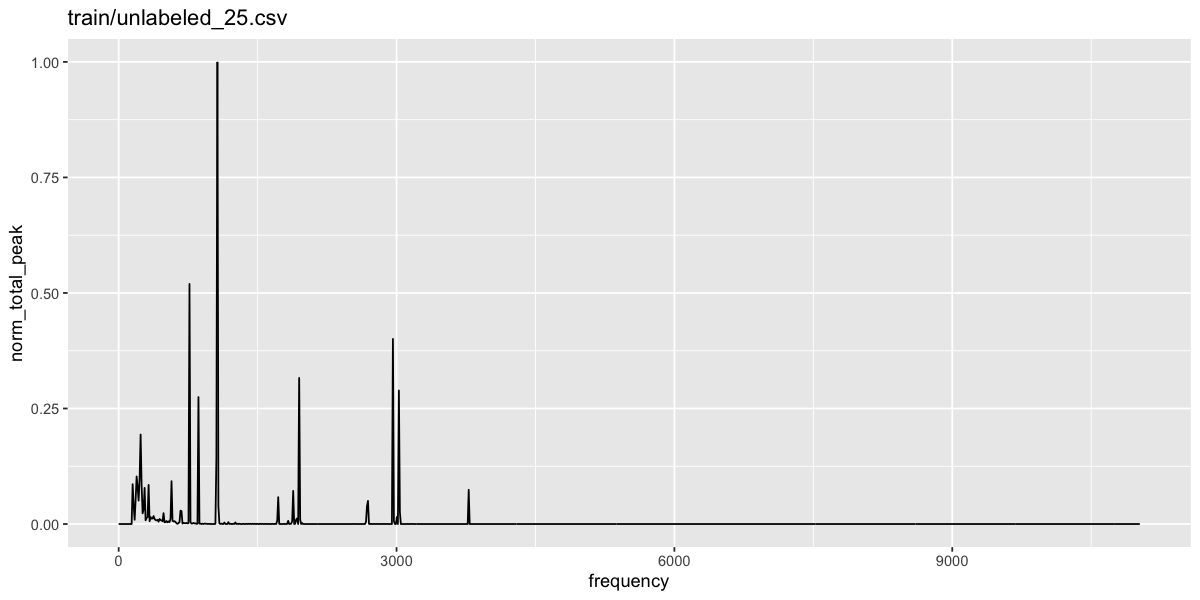

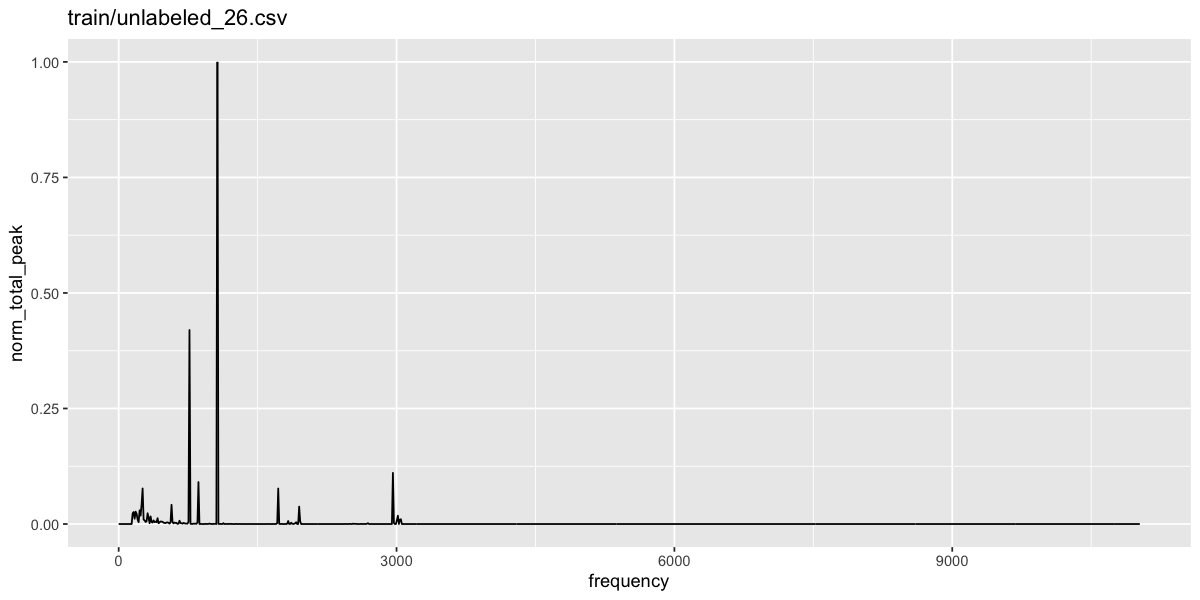

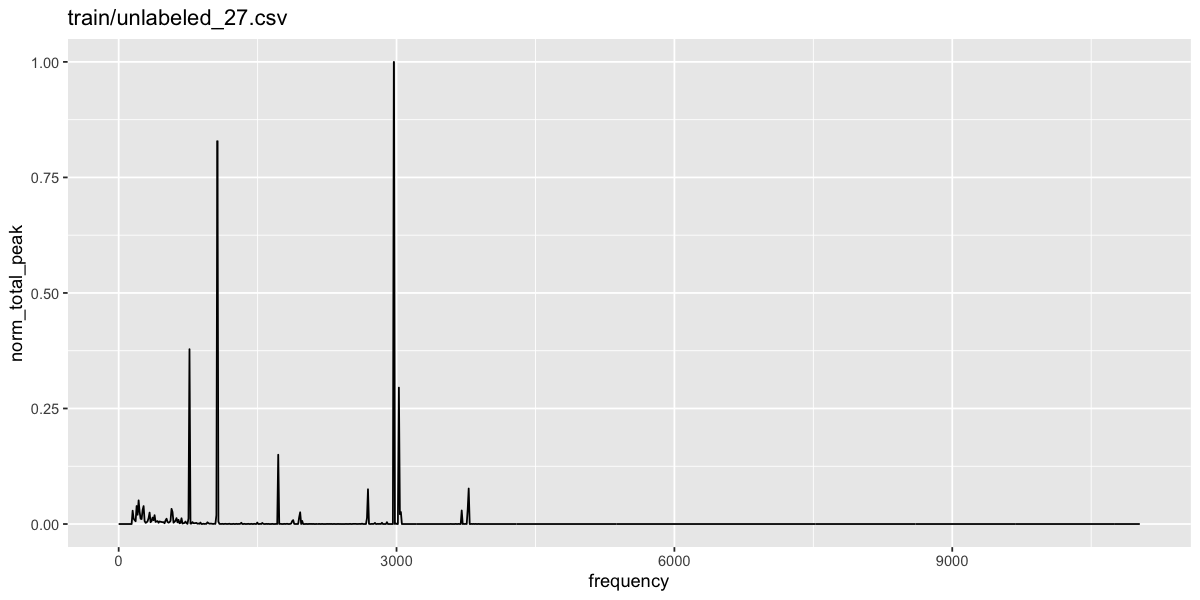

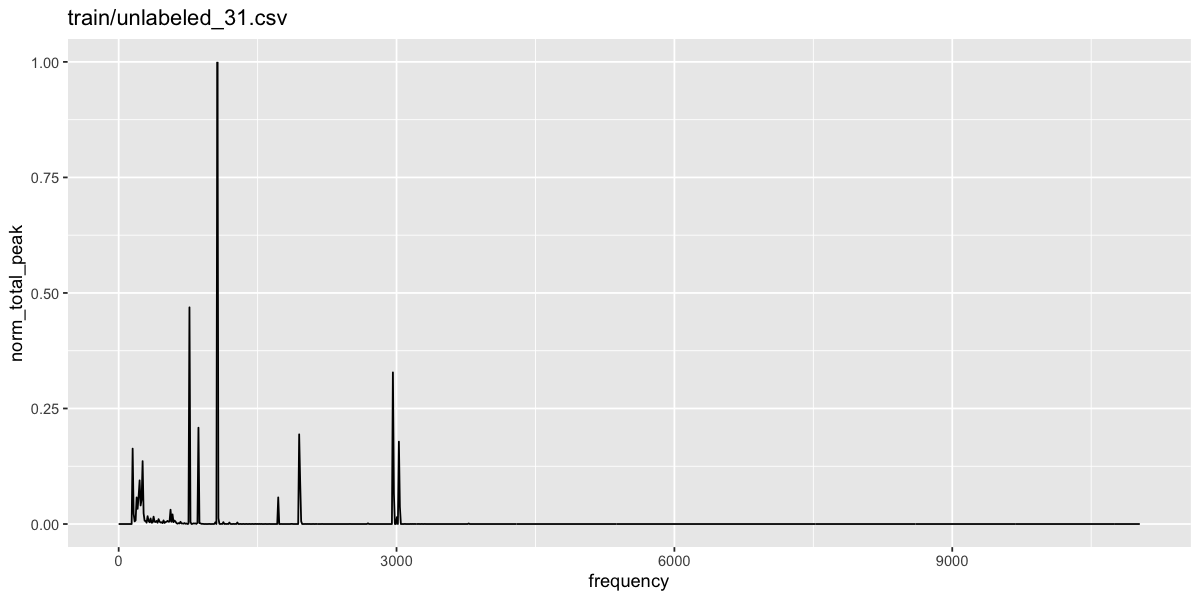

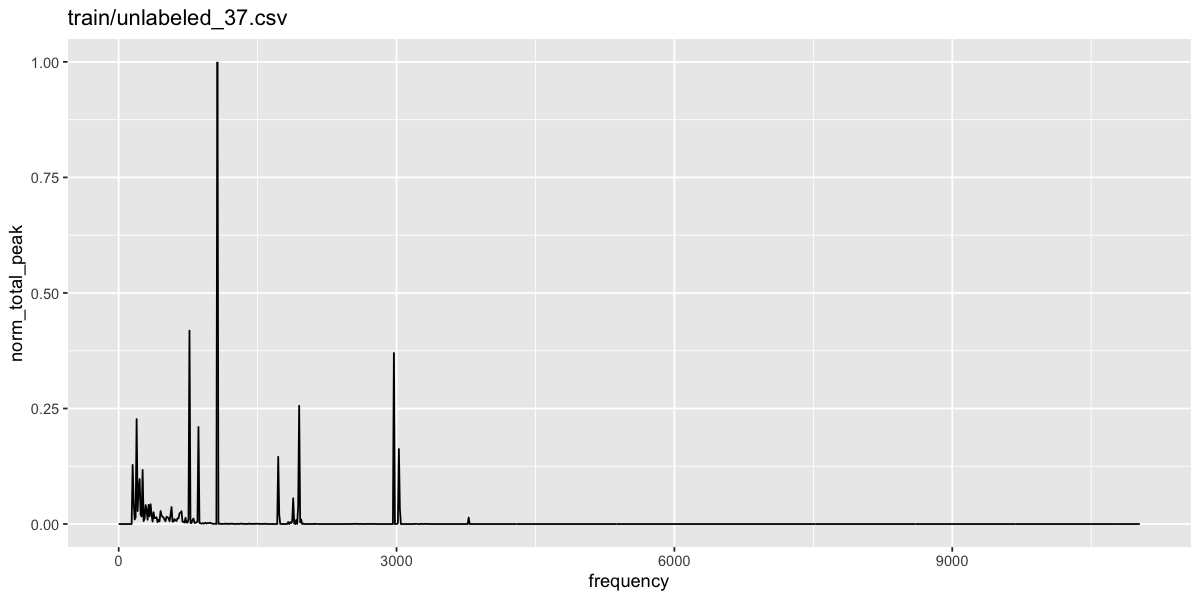

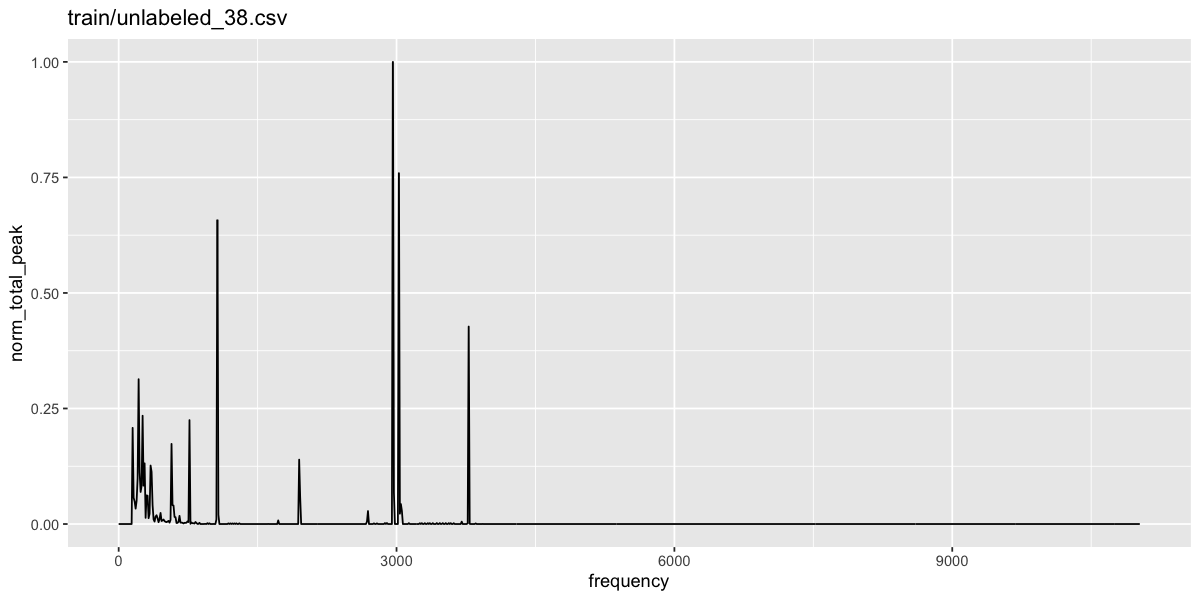

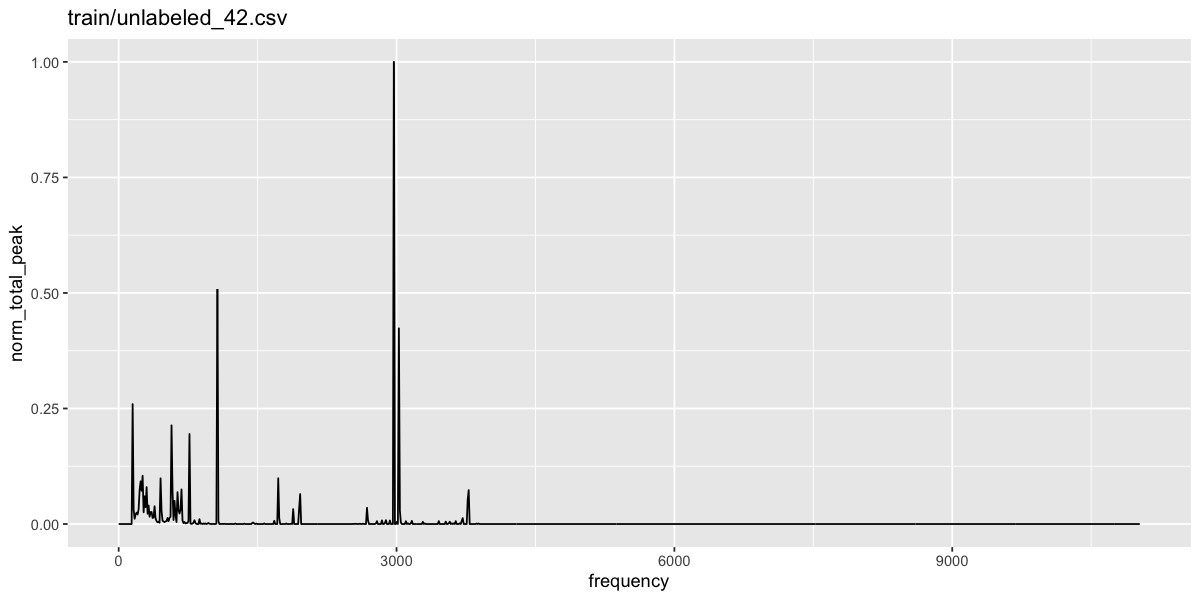

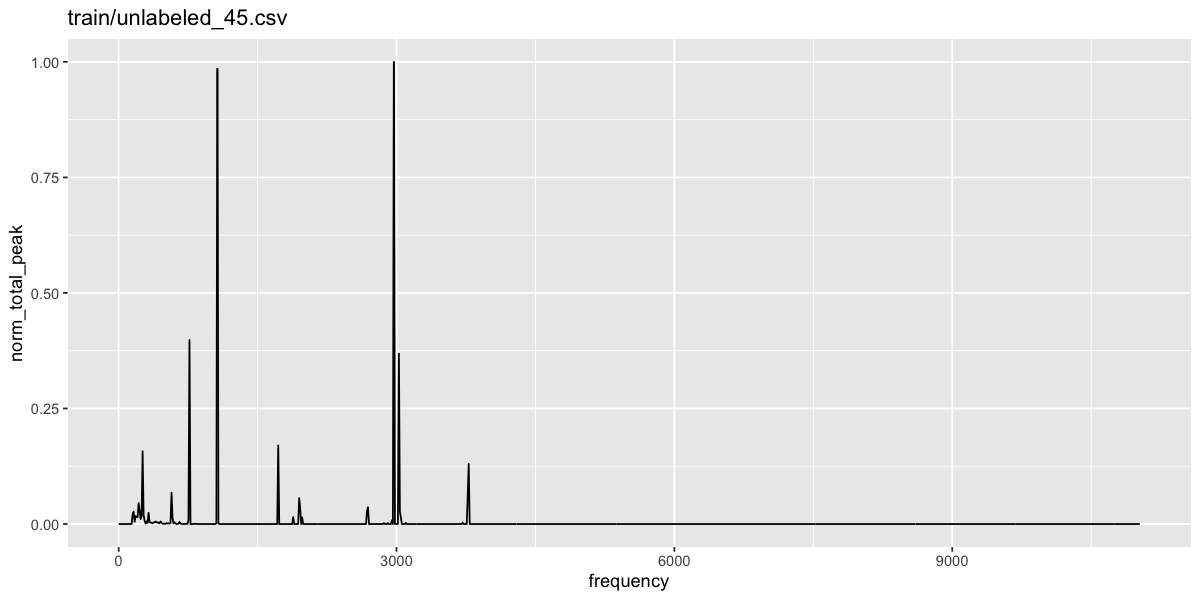

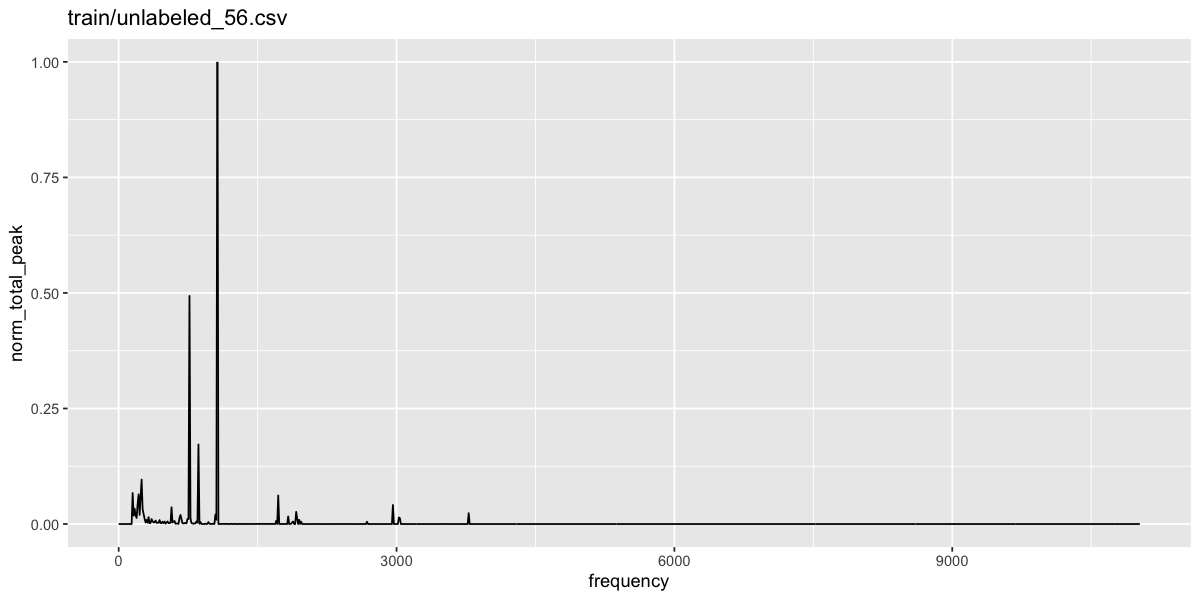

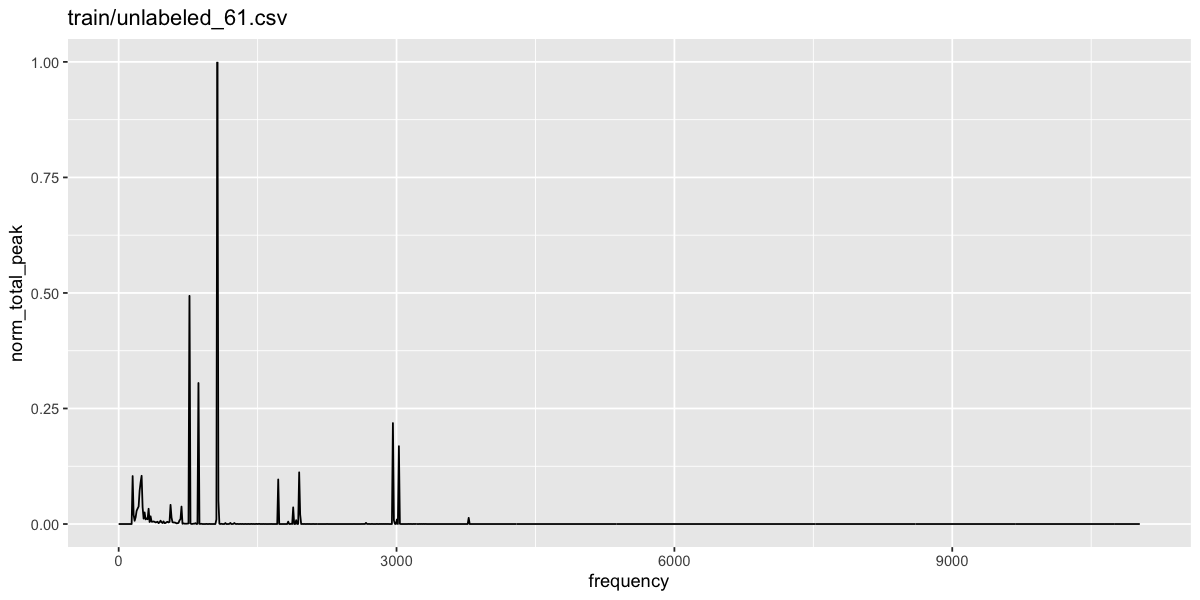

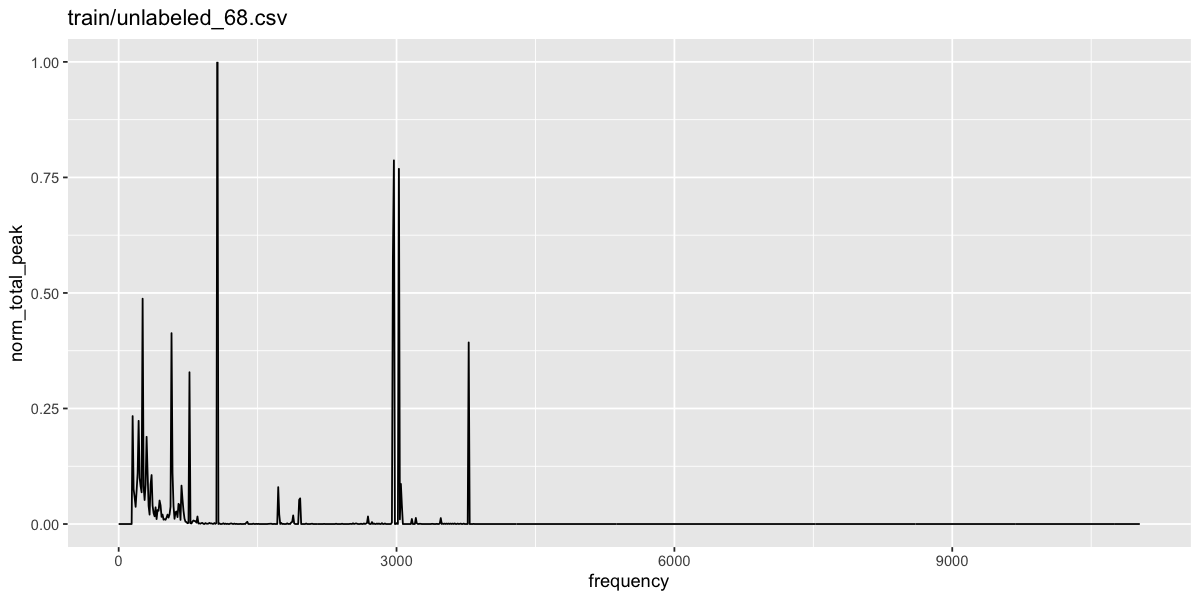

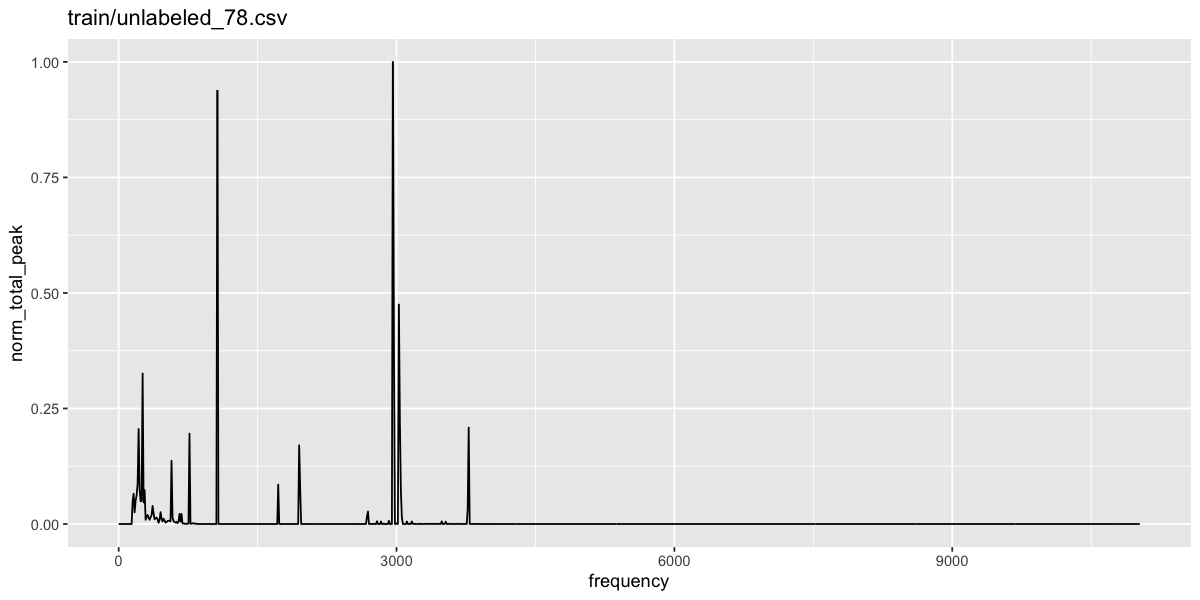

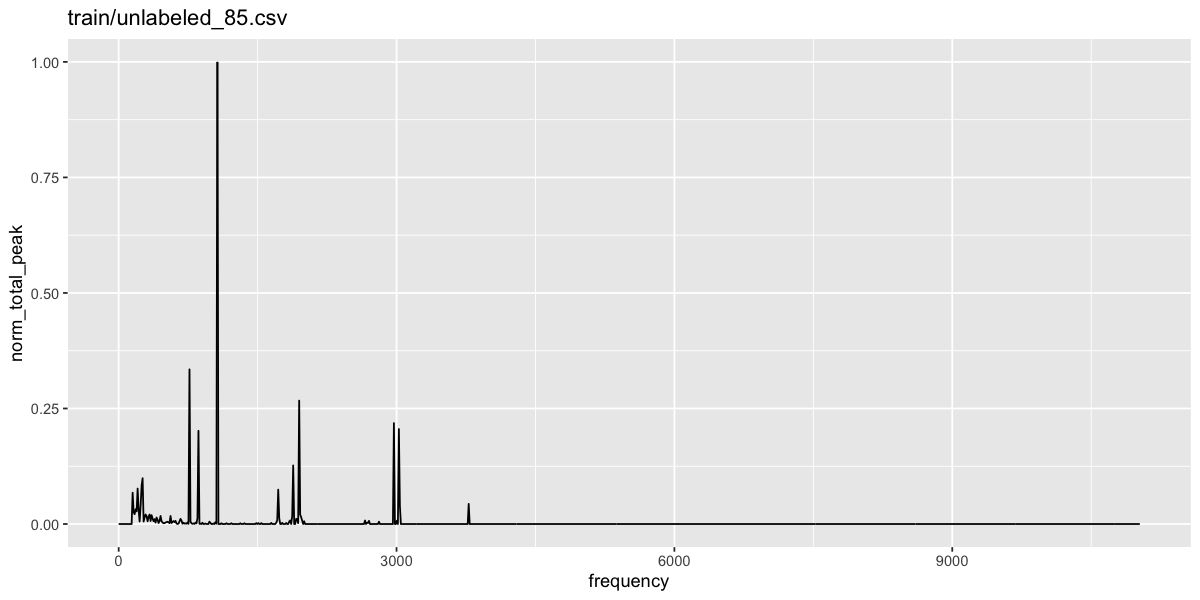

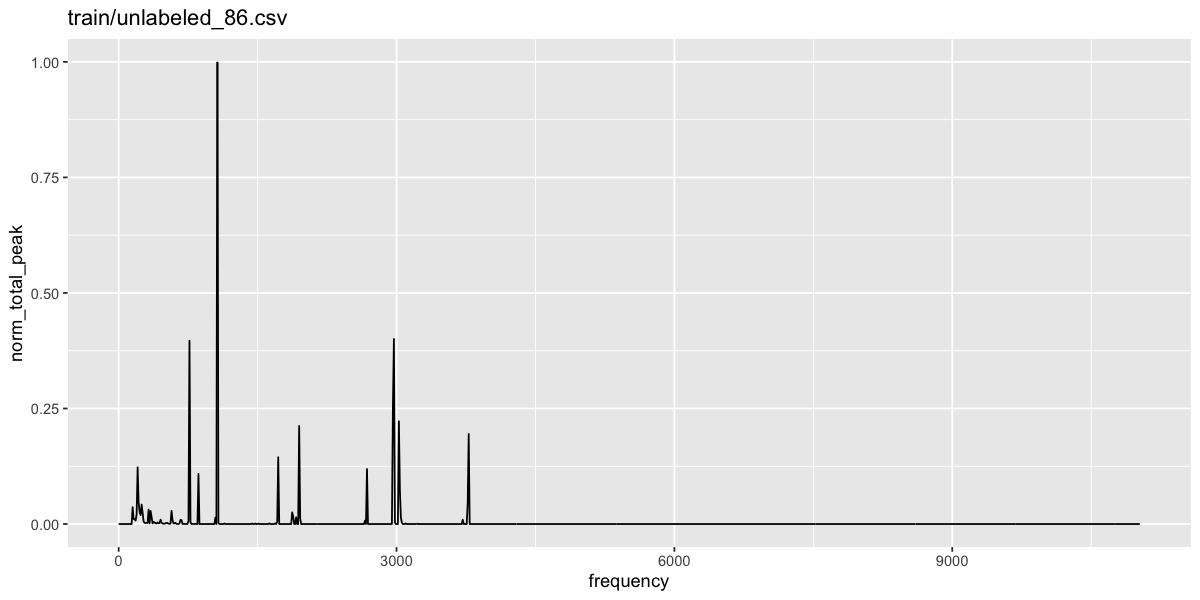

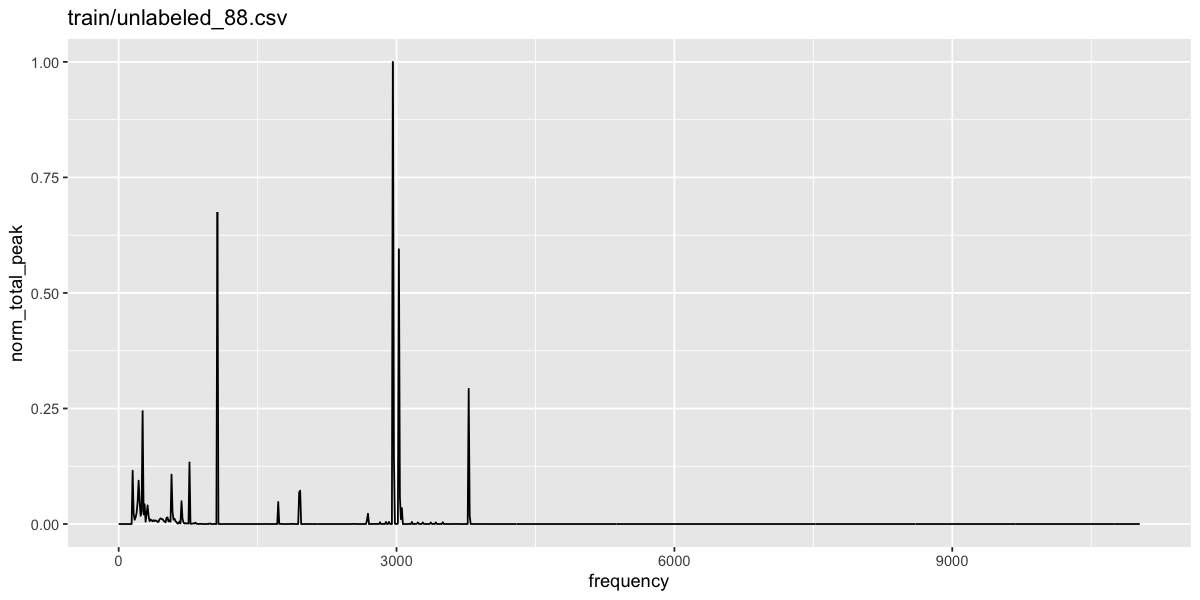

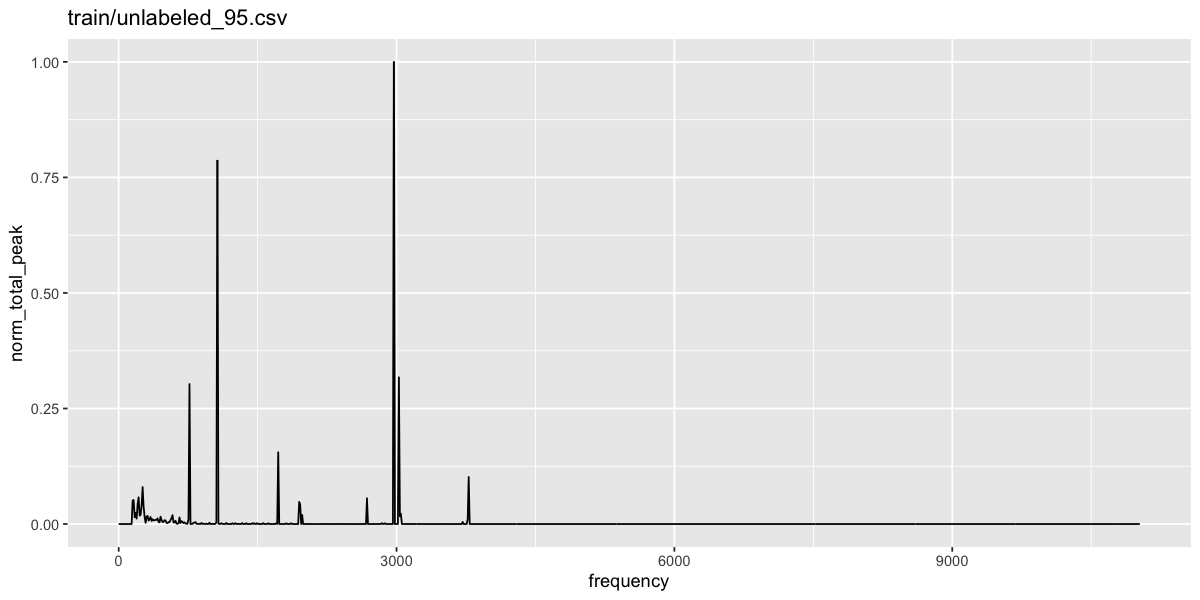

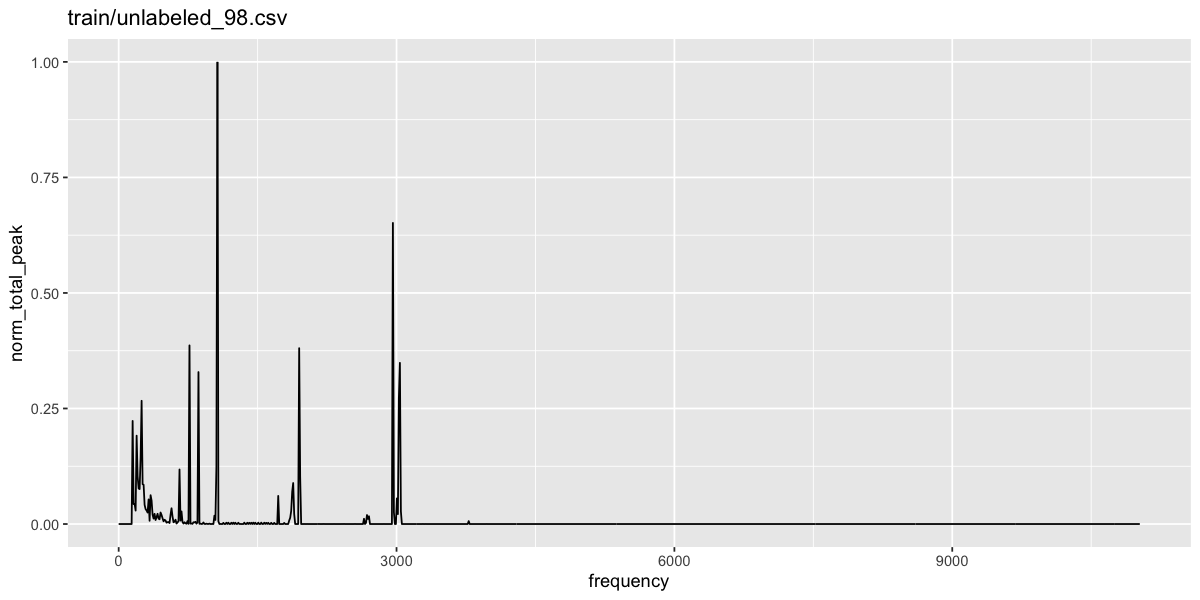

In [29]:
for (fpath in filenames[3:length(filenames)]) {
    p = compute_pct(fpath) %>% ggplot(aes(x = frequency, y = norm_total_peak)) + 
        geom_line() +
        ggtitle(fpath)
    print(p)
}

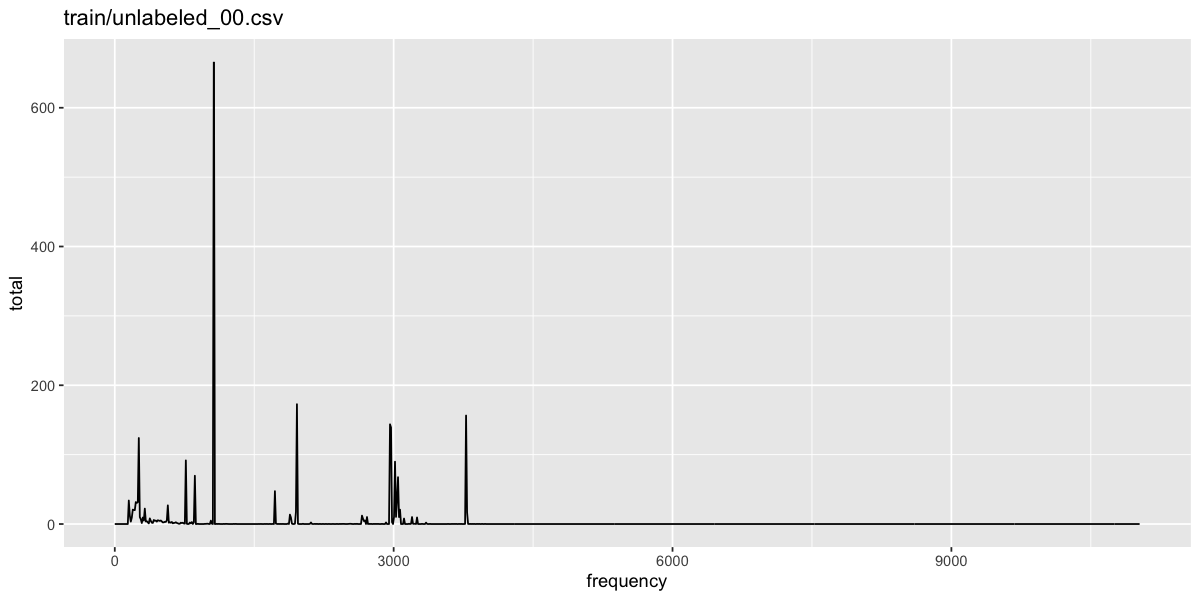

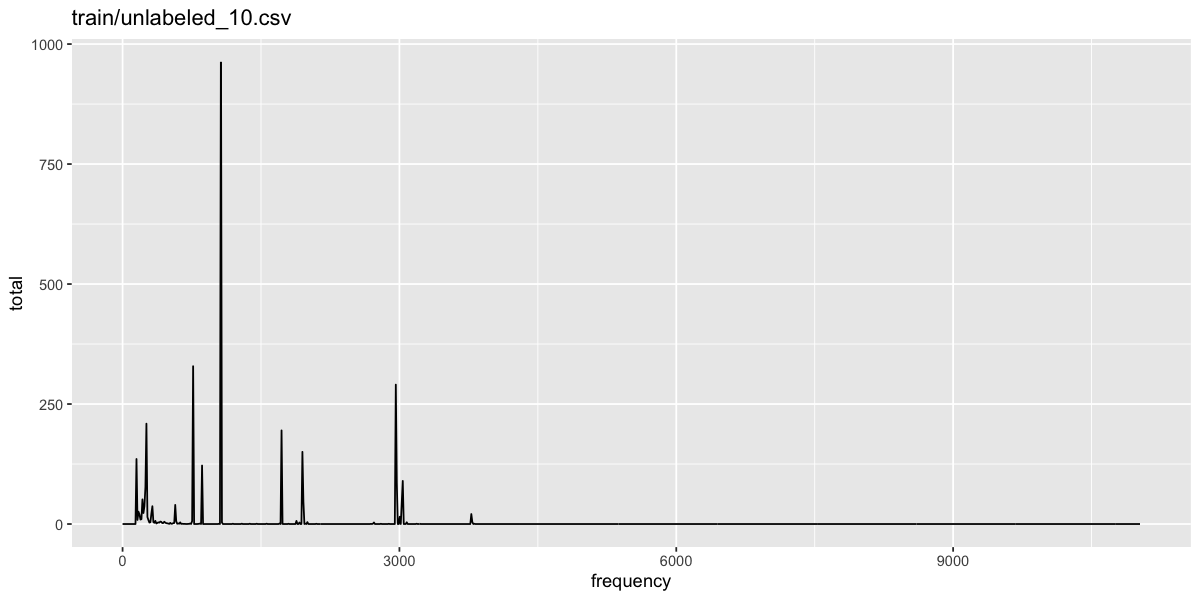

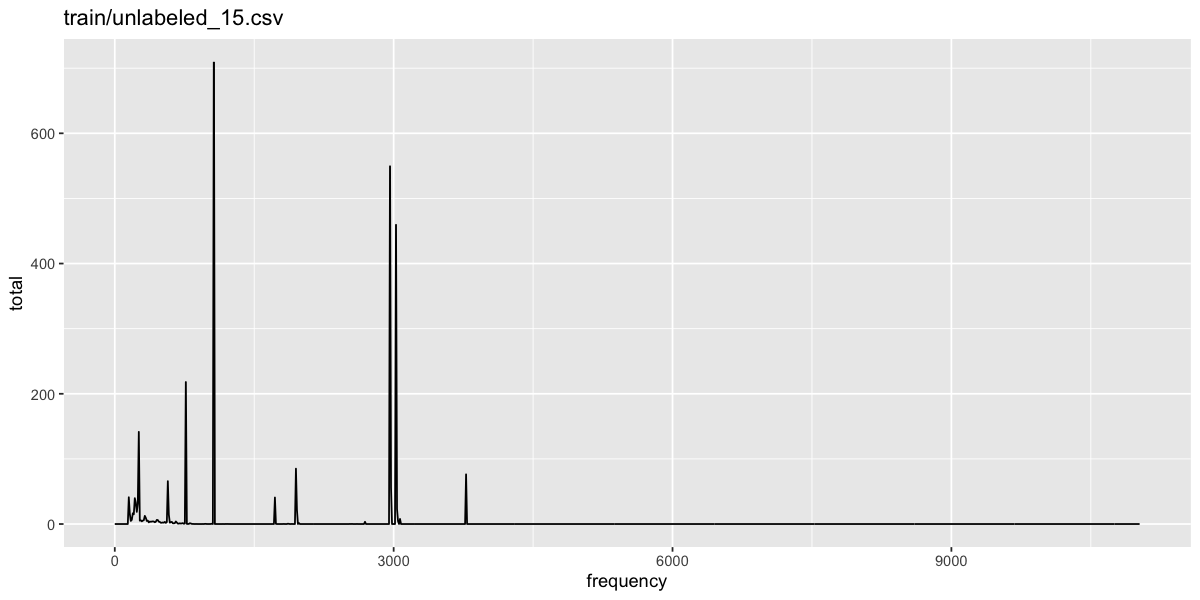

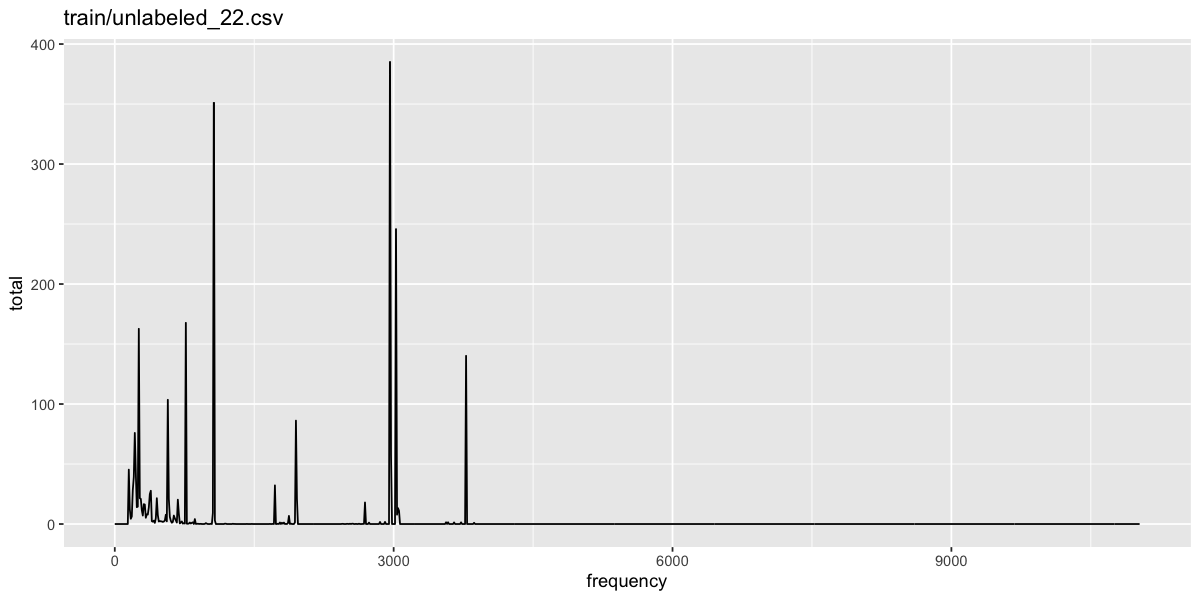

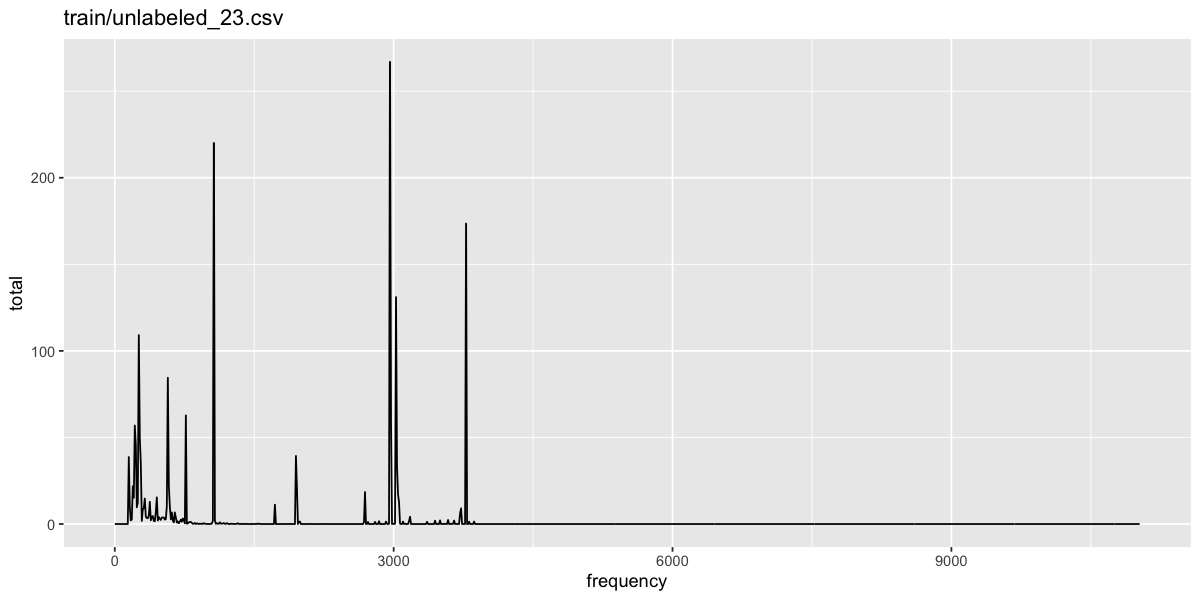

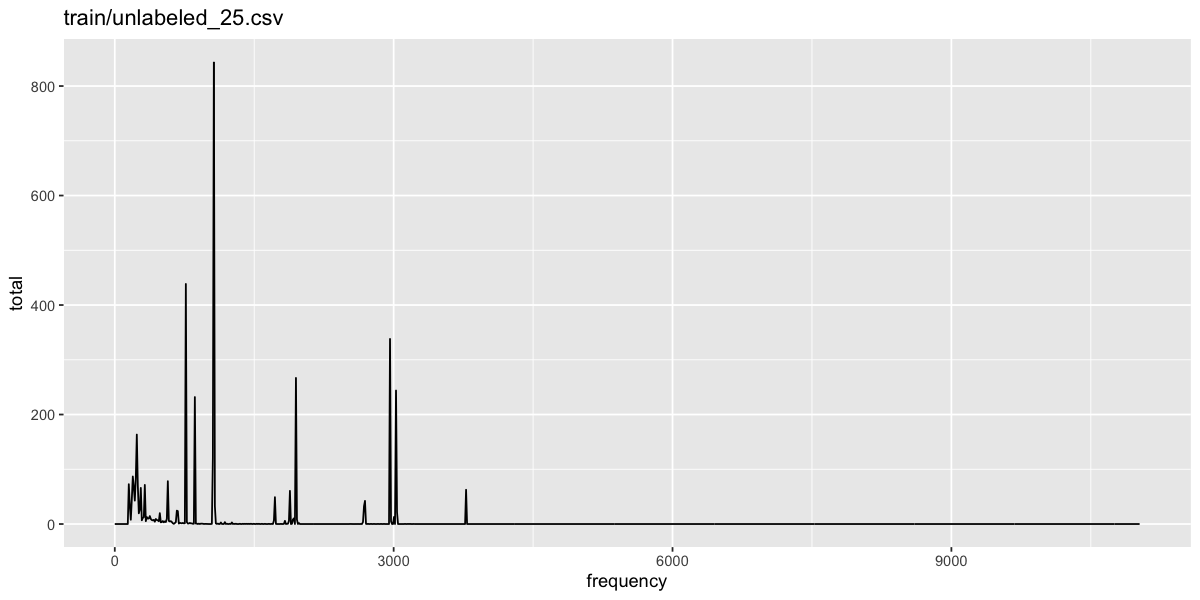

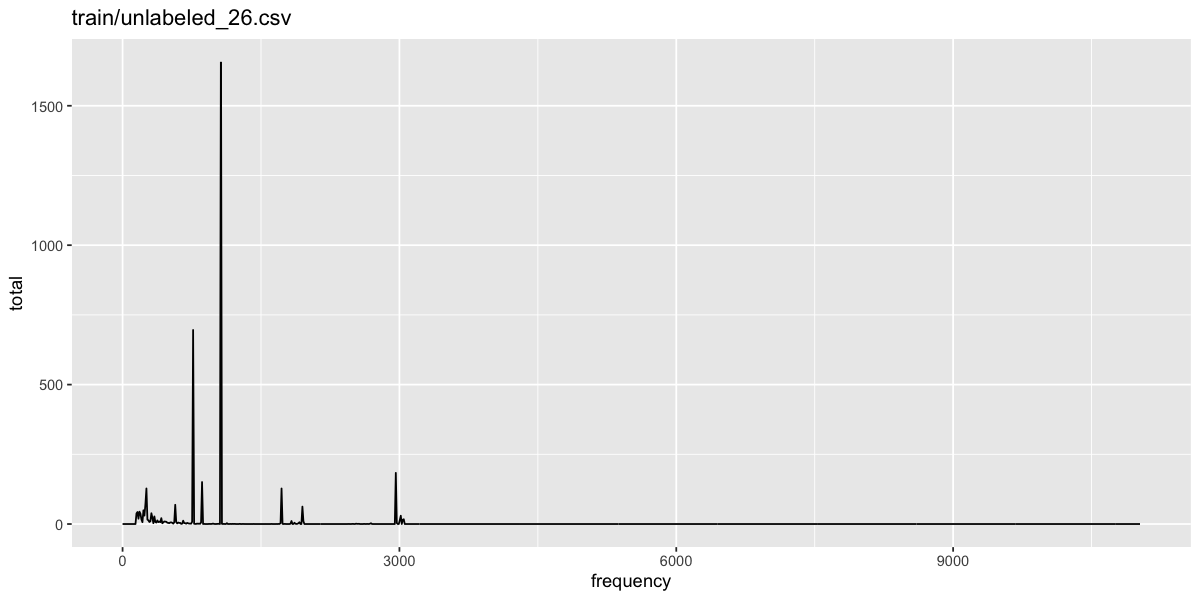

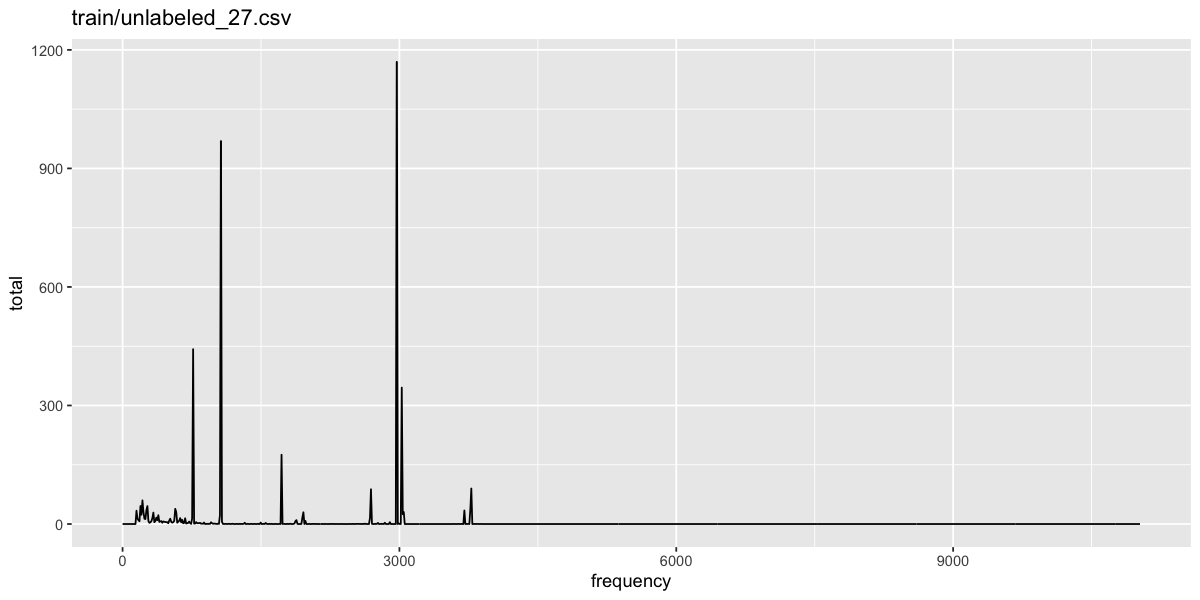

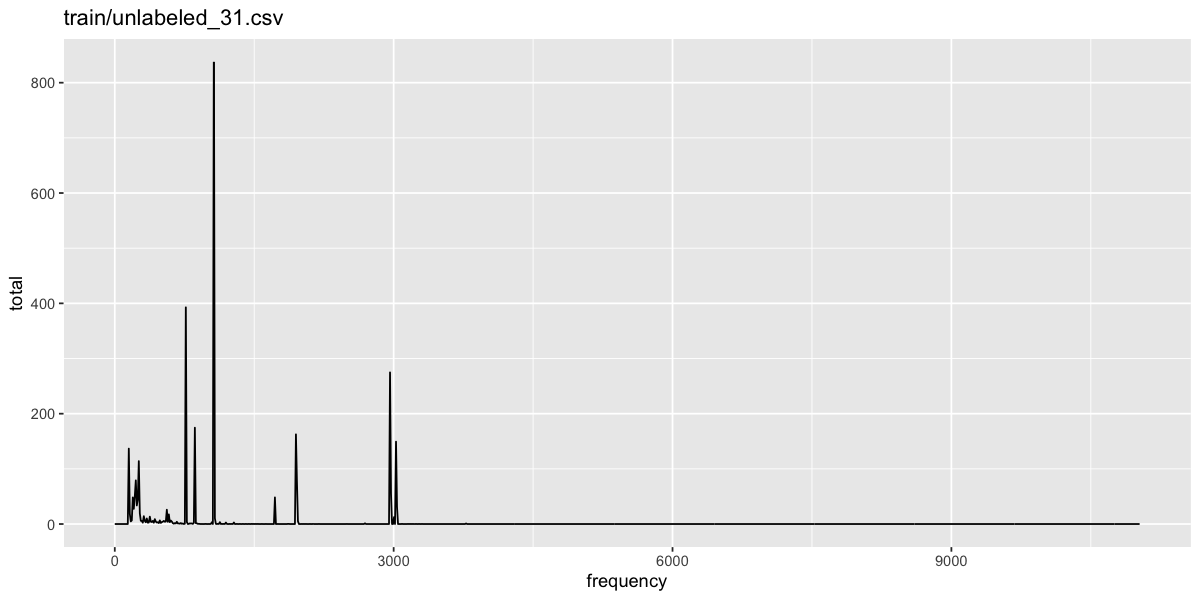

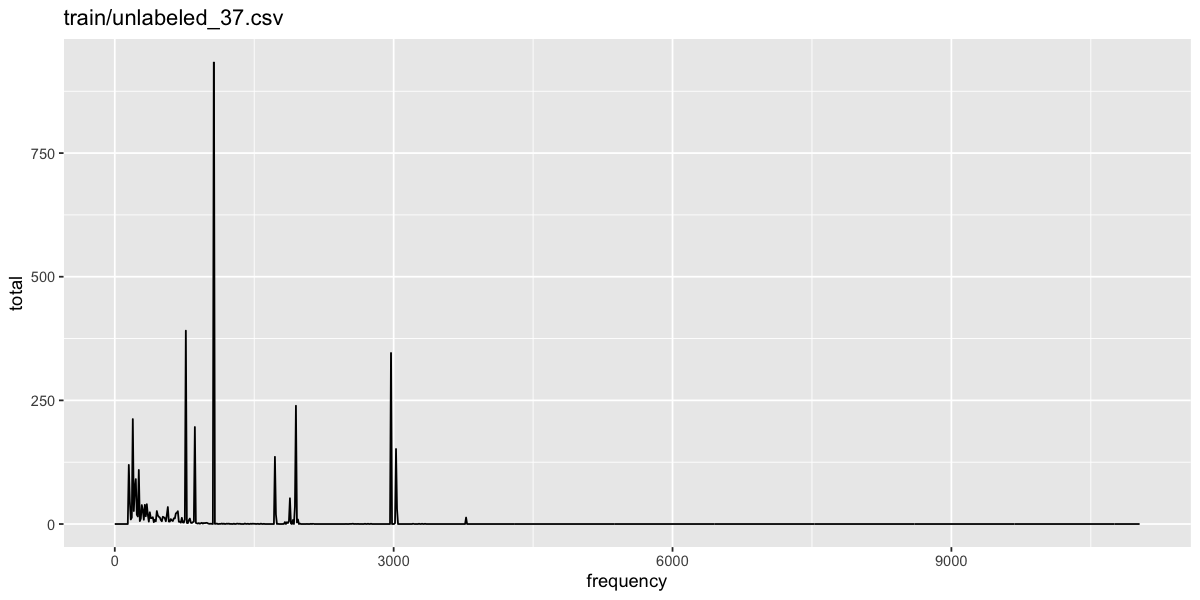

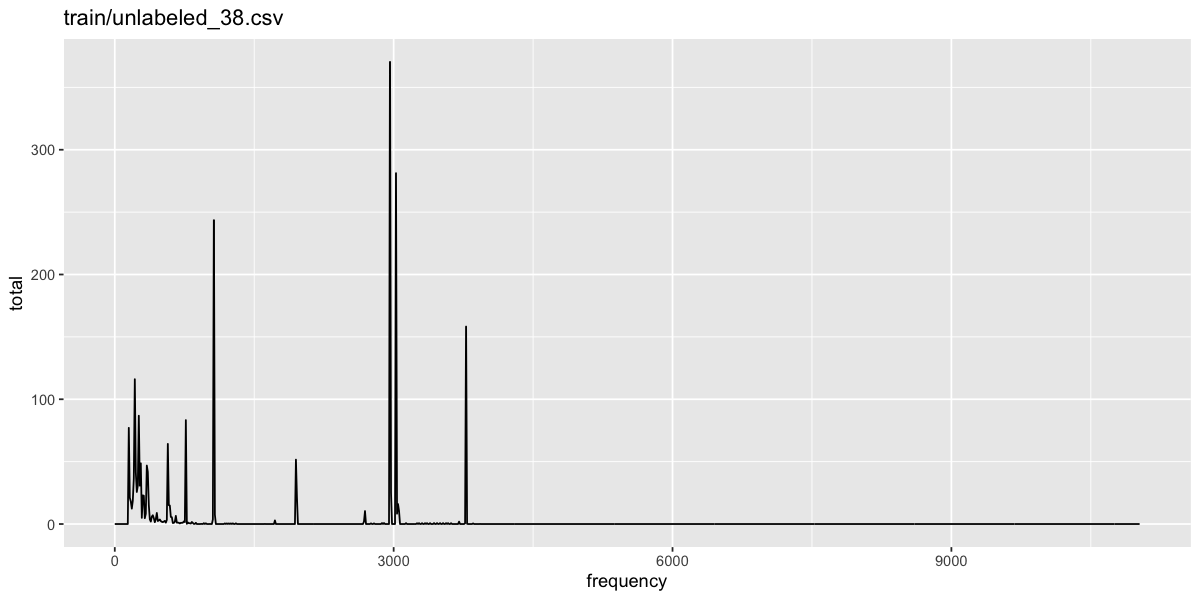

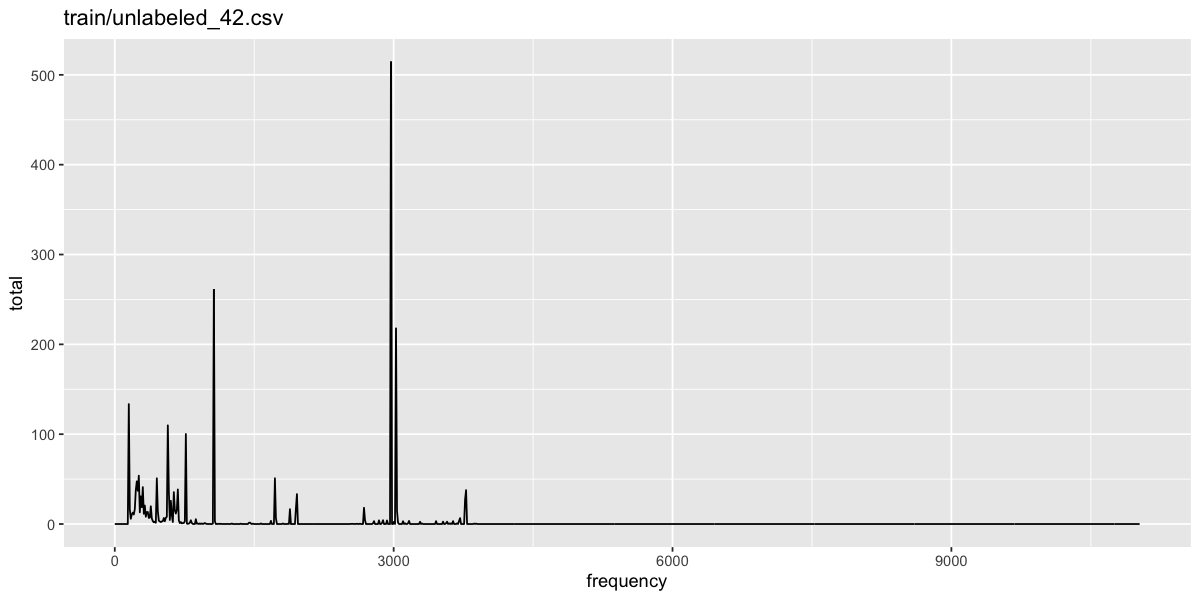

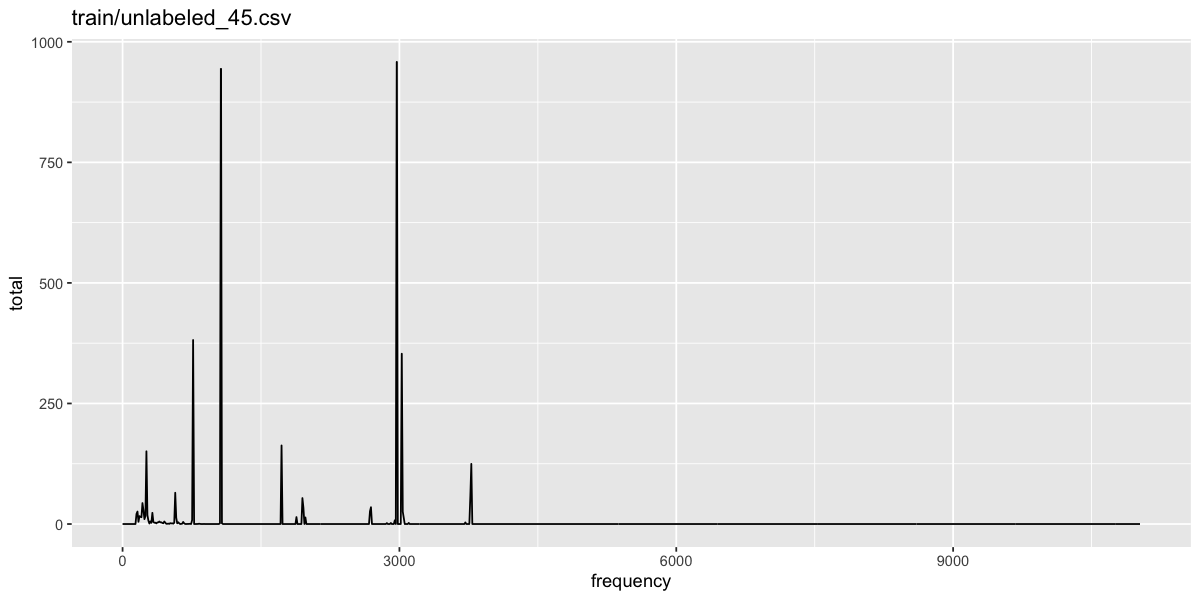

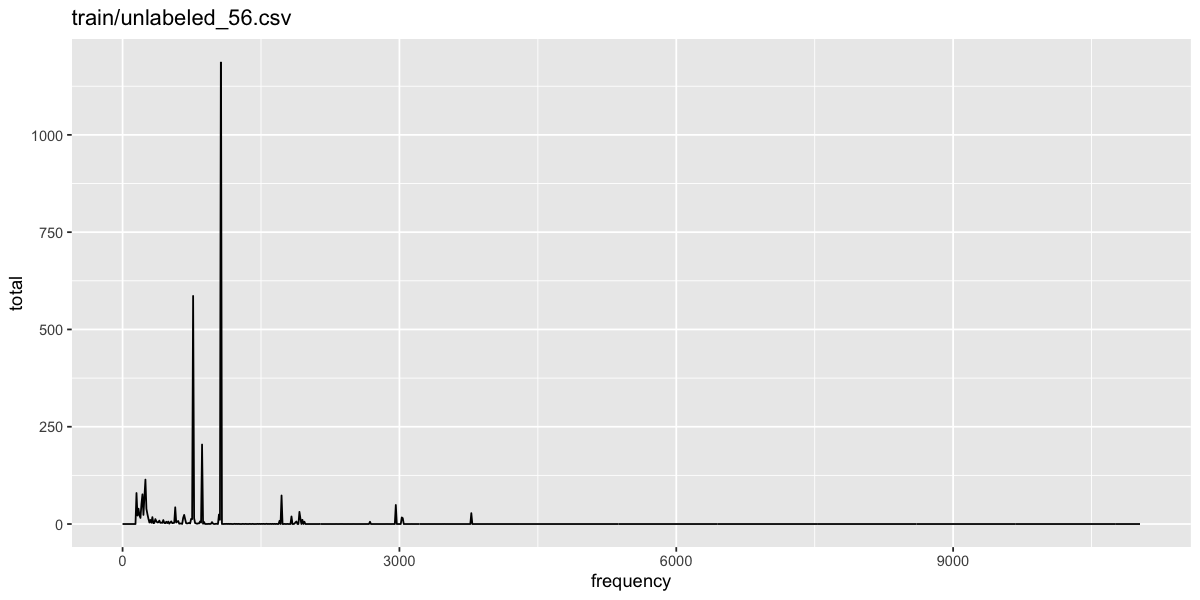

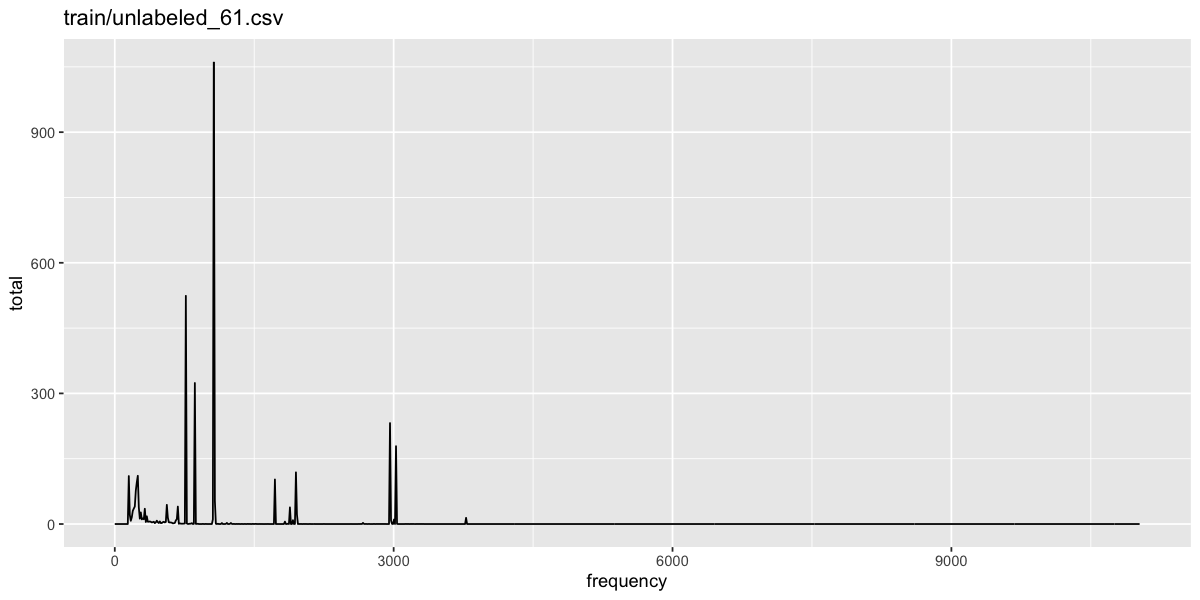

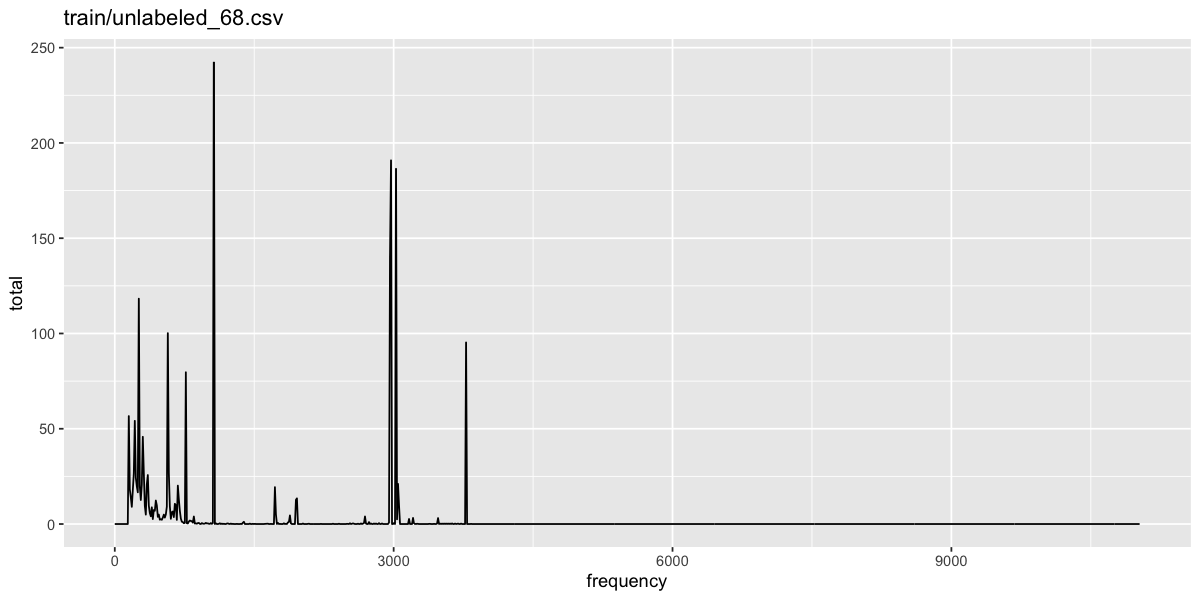

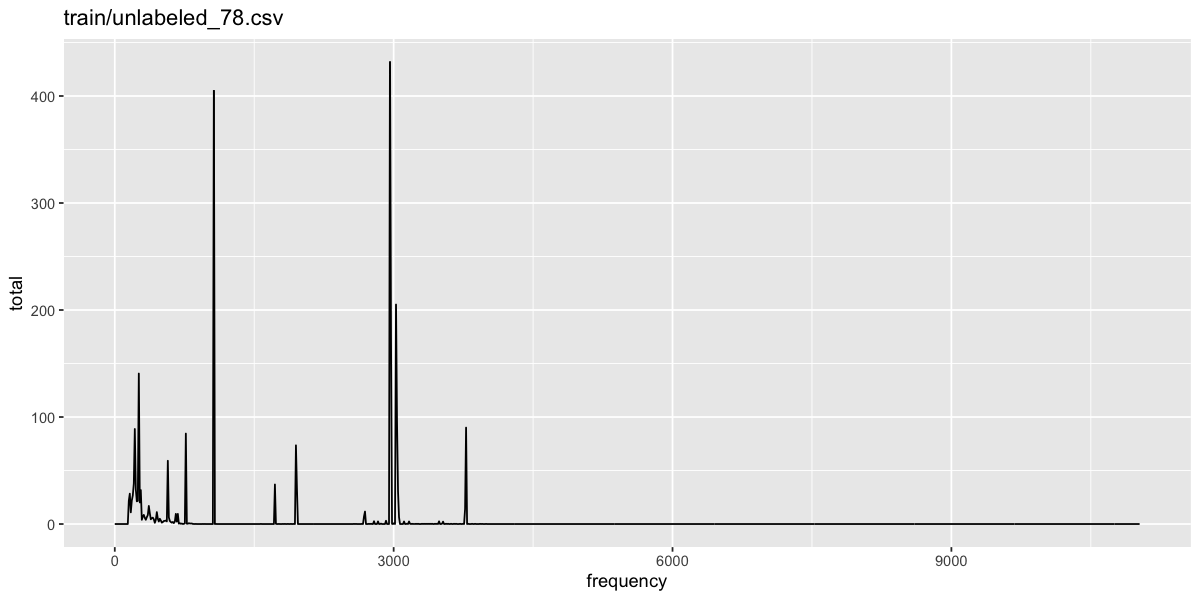

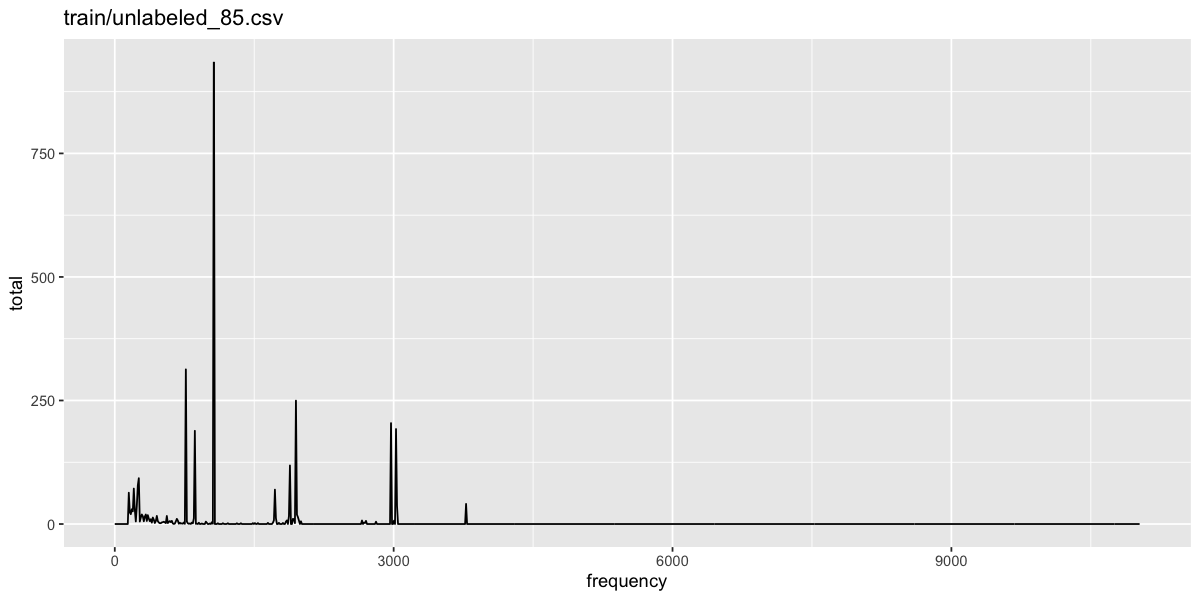

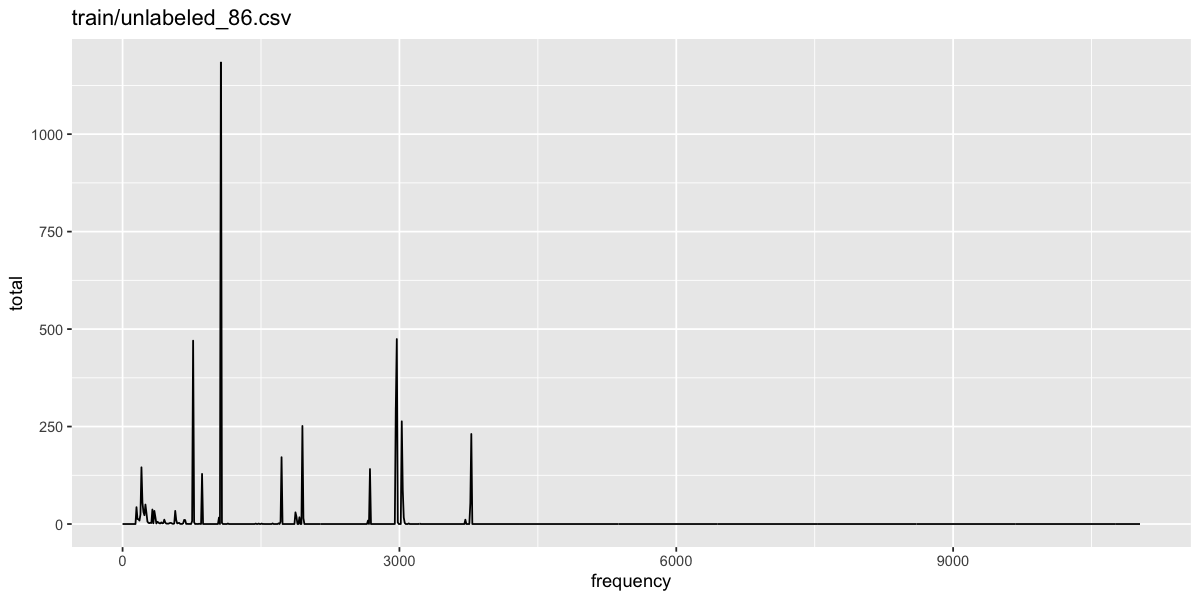

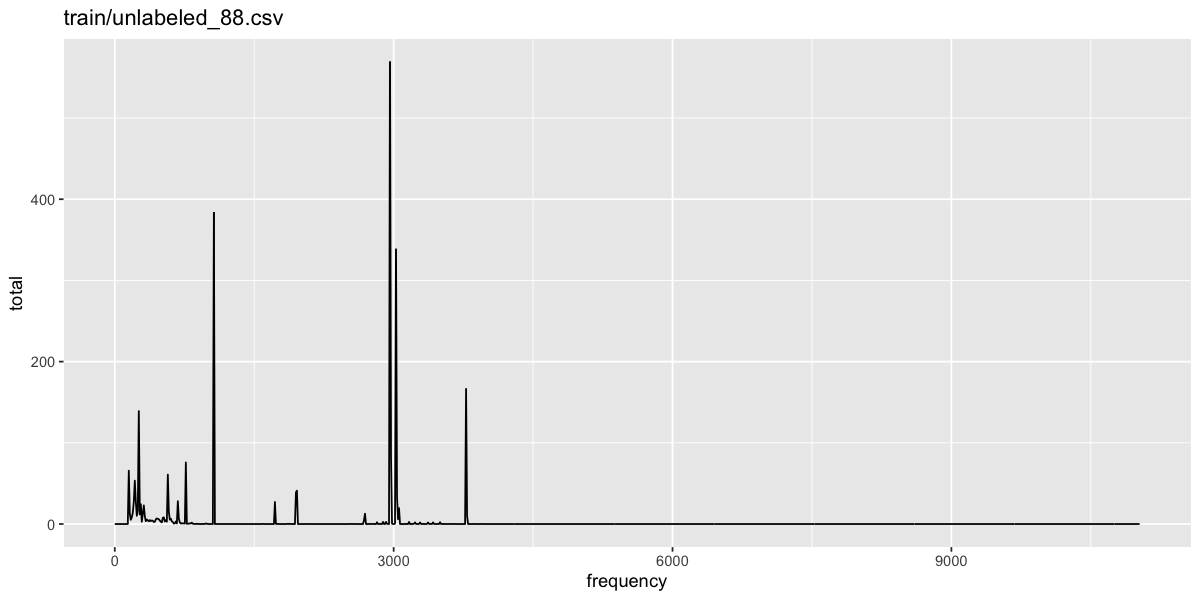

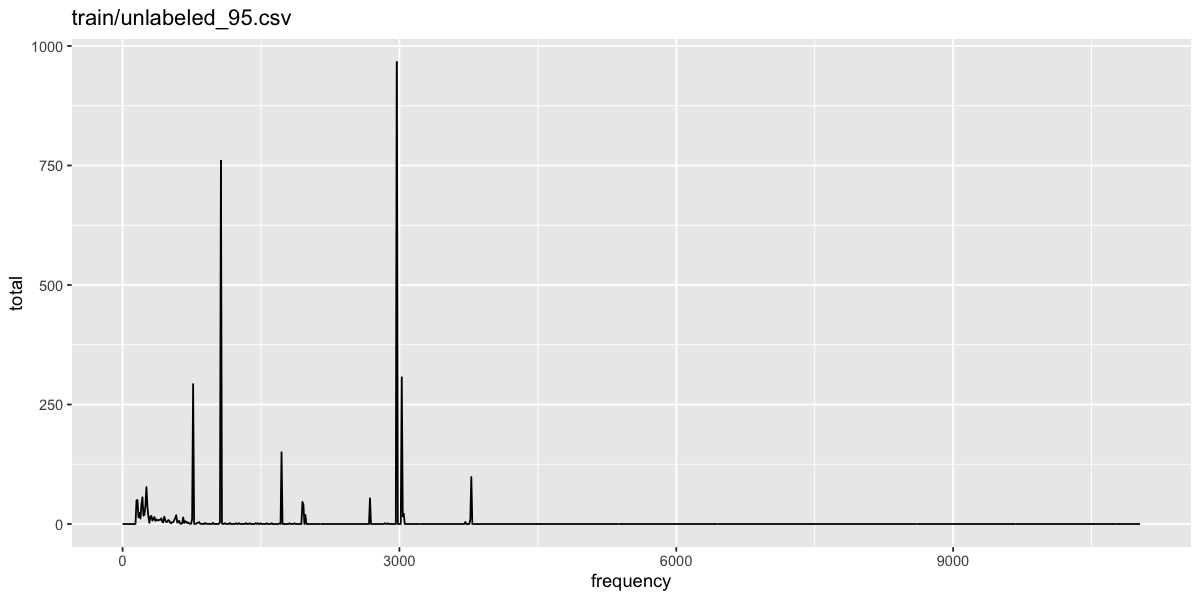

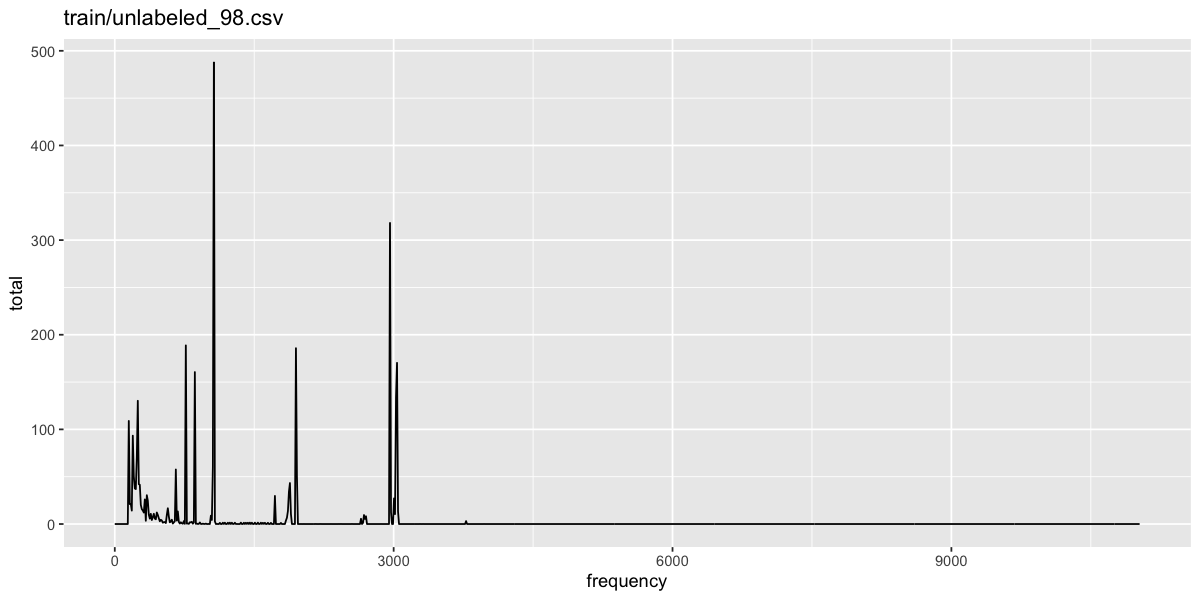

In [30]:
for (fpath in filenames[3:length(filenames)]) {
    p = compute_pct(fpath) %>% ggplot(aes(x = frequency, y = total)) + 
        geom_line() +
        ggtitle(fpath)
    print(p)
}

# K-means to assign pseudolabels

In [31]:
X = sapply(filenames, function(fpath) compute_pct(fpath)$total) %>% t

In [32]:
km = X %>% kmeans(centers = X[1:2,])
km

K-means clustering with 2 clusters of sizes 10, 14

Cluster means:
  [,1] [,2] [,3] [,4] [,5] [,6] [,7] [,8] [,9] [,10] [,11] [,12] [,13] [,14]
1    0    0    0    0    0    0    0    0    0     0     0     0     0     0
2    0    0    0    0    0    0    0    0    0     0     0     0     0     0
     [,15]   [,16]     [,17]    [,18]   [,19]    [,20]    [,21]    [,22]
1 90.71279 24.3712 19.090809 22.63499 50.9007 51.73436 46.85270 48.64803
2 59.51891 19.8635  8.670627 12.85324 25.2458 27.71979 54.17344 32.18889
     [,23]    [,24]     [,25]    [,26]    [,27]     [,28]    [,29]    [,30]
1 55.82372 72.25670  81.11152 13.75531 17.69988 11.407377 12.63196 12.86846
2 24.28052 31.63283 105.87078 25.28316 21.17731  6.786399 14.39018 12.35912
     [,31]    [,32]    [,33]    [,34]    [,35]    [,36]    [,37]    [,38]
1 30.31681 6.699433 15.86025 12.15577 5.054487 9.288908 6.205656 6.643462
2 14.46137 7.277202 12.14417 12.70278 8.207065 8.310234 9.142771 4.963349
     [,39]    [,40]    [,41]    [

In [33]:
km$cluster

train/bottom.csv          train/top.csv train/unlabeled_00.csv 
                     1                      2                      2 
train/unlabeled_10.csv train/unlabeled_15.csv train/unlabeled_22.csv 
                     1                      2                      2 
train/unlabeled_23.csv train/unlabeled_25.csv train/unlabeled_26.csv 
                     2                      1                      1 
train/unlabeled_27.csv train/unlabeled_31.csv train/unlabeled_37.csv 
                     2                      1                      1 
train/unlabeled_38.csv train/unlabeled_42.csv train/unlabeled_45.csv 
                     2                      2                      2 
train/unlabeled_56.csv train/unlabeled_61.csv train/unlabeled_68.csv 
                     1                      1                      2 
train/unlabeled_78.csv train/unlabeled_85.csv train/unlabeled_86.csv 
                     2                      1                      1 
train/unlabeled_88.csv train/unlabeled_95.csv train/unlabeled_98.csv 
                     2                      2                      2

Clusters are of roughly equal size, labeled top and bottom instances are in different clusters.

In [34]:
all.equal(filenames, names(km$cluster))

[1] TRUE

In [35]:
y = factor(km$cluster)

# Dimension reduction (PCA)

In [36]:
X = sapply(filenames, function(fpath) compute_pct(fpath)$total) %>% t

In [37]:
dim(X)

[1]   24 1025

In [38]:
pc.out = prcomp(X)

In [39]:
pcs = pc.out$rotation

In [40]:
proj = X %*% pcs

In [41]:
proj = as.data.frame(proj)

In [42]:
dim(proj)

[1] 24 24

In [43]:
proj$y = y

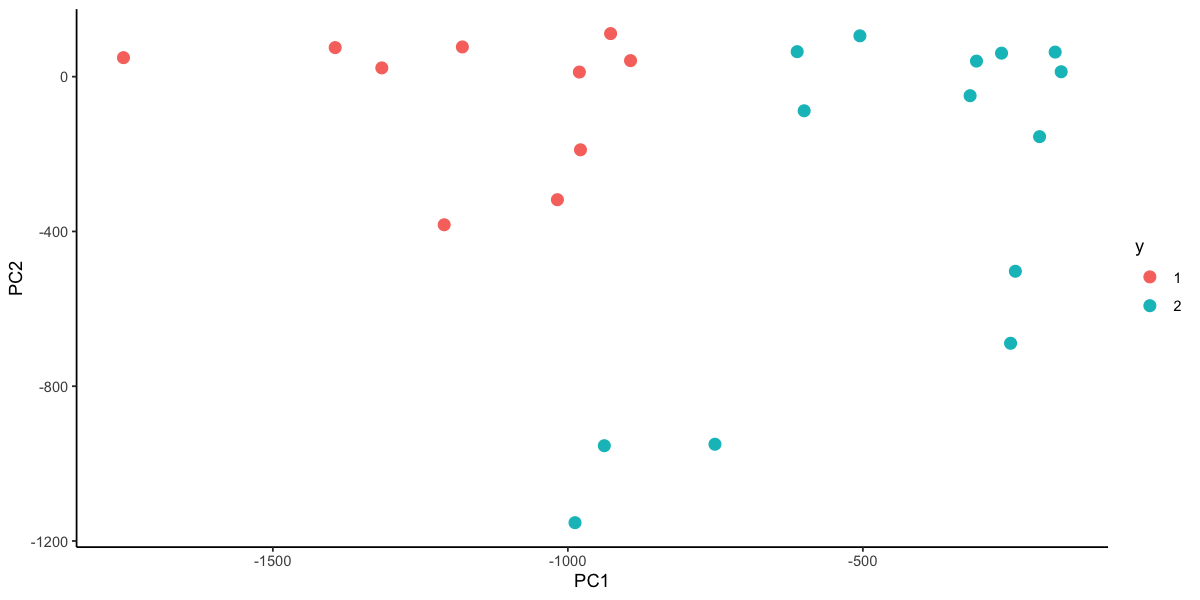

In [44]:
proj %>% ggplot(aes(x = PC1, y = PC2)) + geom_point(aes(color=y), size=3) + theme_classic()

In [45]:
Z = scale(X, center = TRUE, scale = FALSE)
Z.svd = svd(Z, nu=0, nv=0)
eigvals = (Z.svd$d)^2
pct.var = (eigvals / sum(eigvals))*100

In [46]:
cumsum(pct.var)

[1]  49.47000  84.70291  90.98850  93.86124  95.42025  96.38488  97.32373
 [8]  97.90182  98.36606  98.72590  99.01954  99.23231  99.39062  99.52771
[15]  99.62180  99.71063  99.79180  99.84772  99.89346  99.93095  99.95710
[22]  99.98142 100.00000 100.00000

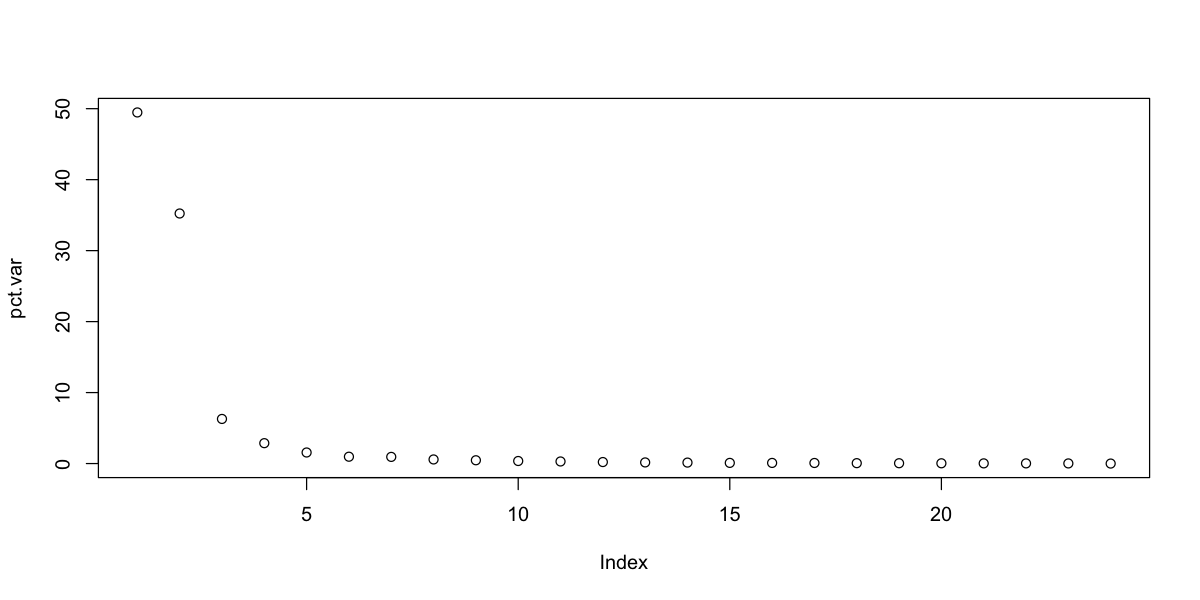

In [47]:
plot(pct.var)

In [48]:
Z = scale(X, center = TRUE, scale = FALSE)
Z.svd = svd(Z, nu=0, nv=0)
eigvals = (Z.svd$d)^2
pct.var = (eigvals / sum(eigvals))*100

In [49]:
cumsum(pct.var)

[1]  49.47000  84.70291  90.98850  93.86124  95.42025  96.38488  97.32373
 [8]  97.90182  98.36606  98.72590  99.01954  99.23231  99.39062  99.52771
[15]  99.62180  99.71063  99.79180  99.84772  99.89346  99.93095  99.95710
[22]  99.98142 100.00000 100.00000

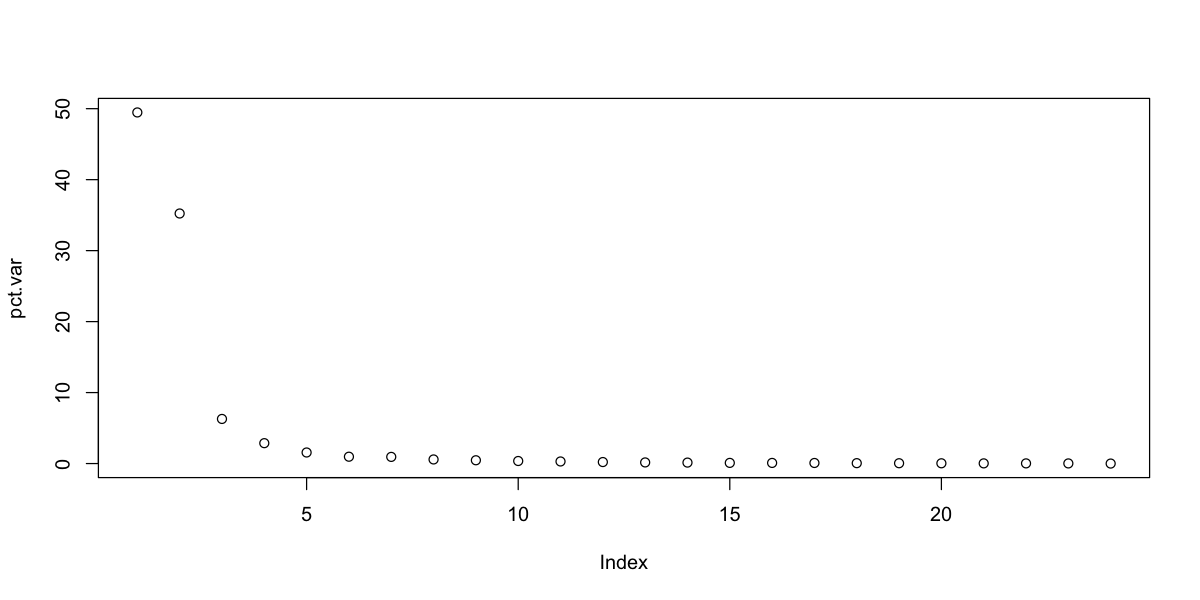

In [50]:
plot(pct.var)

# LDA

In [51]:
X_pc = X %*% pcs
dim(X_pc)

[1] 24 24

In [52]:
n1 = sum(y==1)
n2 = sum(y==2)

In [53]:
mu1 = X_pc[y==1,1:2] %>% colMeans %>% matrix(2, 1)
mu2 = X_pc[y==2,1:2] %>% colMeans %>% matrix(2, 1)

In [54]:
S1 = cov(X_pc[y==1,1:2])
S2 = cov(X_pc[y==2,1:2])
Sp = ((n1-1)*S1 + (n2-1)*S2)/(n1+n2-2)
Sp.inv = solve(Sp)

In [55]:
n = n1 + n2
prior = c(n2, n1)/n

In [56]:
b0 = log(prior[2]/prior[1]) - 0.5*t(mu2+mu1) %*% Sp.inv %*% (mu2-mu1)
b1 = Sp.inv %*% (mu2-mu1) %>% as.numeric

In [57]:
b1

[1]  0.013317068 -0.006531019

In [58]:
b0

9.281324


In [59]:
(X_pc[,1:2] %*% b1 + as.numeric(b0) > 0) %>% table

.
FALSE  TRUE 
   10    14 

In [60]:
ifelse(X_pc[,1:2] %*% b1 + as.numeric(b0) > 0, 2, 1) == y

train/bottom.csv,TRUE
train/top.csv,TRUE
train/unlabeled_00.csv,TRUE
train/unlabeled_10.csv,TRUE
train/unlabeled_15.csv,TRUE
train/unlabeled_22.csv,TRUE
train/unlabeled_23.csv,TRUE
train/unlabeled_25.csv,TRUE
train/unlabeled_26.csv,TRUE
train/unlabeled_27.csv,TRUE
train/unlabeled_31.csv,TRUE


# Dimension reduction revisited

The desired function won't be able to project onto PC space without access to the PCs. Find an alternative?

In [61]:
pc1 = pc.out$rotation[,'PC1']
pc2 = pc.out$rotation[,'PC2']

In [62]:
round(pc1, 2) %>% table

.
-0.87 -0.43 -0.15 -0.09 -0.07 -0.04 -0.02 -0.01     0  0.01  0.02  0.03  0.06 
    1     1     1     1     1     1     3    17   982     8     4     2     1 
 0.09   0.1 
    1     1 

In [63]:
round(pc2, 2) %>% table

.
-0.92 -0.12 -0.08 -0.03 -0.01     0  0.01  0.02  0.03  0.04  0.06  0.11  0.32 
    1     1     1     4    12   989     9     3     1     1     1     1     1 

In [64]:
1025-989

[1] 36

In [65]:
pc1[which(round(pc1, 2)!=0)] %>% round(3) %>% print

 [1] -0.006 -0.008 -0.013 -0.012 -0.017 -0.020  0.016 -0.008 -0.022 -0.042
[11]  0.031  0.010  0.013  0.005 -0.014  0.008  0.033  0.011  0.006 -0.006
[21] -0.006 -0.425 -0.154 -0.005 -0.005 -0.867 -0.006 -0.087 -0.009 -0.014
[31] -0.010 -0.005 -0.073  0.018 -0.014  0.099  0.017  0.089  0.024  0.009
[41]  0.008 -0.005  0.063


In [66]:
pc2[which(round(pc2, 2)!=0)] %>% round(3) %>% print

 [1]  0.023 -0.007  0.007  0.007  0.017  0.032  0.038  0.016 -0.009  0.011
[11]  0.007  0.006 -0.008 -0.006 -0.006 -0.013 -0.007  0.110  0.013 -0.015
[21]  0.007 -0.084  0.060 -0.009 -0.027 -0.025  0.324 -0.921  0.007  0.006
[31] -0.122 -0.010 -0.010 -0.010 -0.031 -0.032


In [67]:
(which(round(pc1, 2)!=0) -1) %>% print # Python is 0-indexed

 [1]  14  15  16  17  18  19  20  21  22  23  24  25  26  28  30  42  53  54  55
[20]  62  70  71  80  97  98  99 100 160 170 175 178 179 181 182 249 275 276 281
[39] 282 283 284 350 351


In [68]:
(which(round(pc2, 2)!=0) -1) %>% print # Python is 0-indexed

 [1]  14  15  16  18  21  22  23  24  25  26  29  30  31  36  42  54  70  80  98
[20]  99 100 160 181 184 249 250 275 276 279 280 281 282 283 344 350 351


In [69]:
X_pc["train/top.csv",][1:2]

PC1       PC2 
-249.6778 -688.9874

In [70]:
X_pc[,1:2] %*% b1 + as.numeric(b0) %>% head()

train/bottom.csv,-9.7781285
train/top.csv,10.4561387
train/unlabeled_00.csv,1.8735167
train/unlabeled_10.csv,-3.8540044
train/unlabeled_15.csv,0.7180014
train/unlabeled_22.csv,4.9242181
train/unlabeled_23.csv,7.0158408
train/unlabeled_25.csv,-3.7983860
train/unlabeled_26.csv,-14.3868744
train/unlabeled_27.csv,3.6532822
train/unlabeled_31.csv,-2.8916770


Since the Python classification function should have only a filepath as argument, hard code the nonzero PC coefficients (and LDA coefficients) into that function.